In [1]:
import Model_Training_Module as module

# Cơ bản & xử lý dữ liệu
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats.mstats import winsorize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: tiền xử lý & chia tập
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import SelectFromModel

# Scikit-learn: đánh giá mô hình
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import make_scorer, mean_absolute_percentage_error

# Scikit-learn: mô hình ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Mô hình nâng cao
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from lightgbm import early_stopping, log_evaluation

# Bỏ cảnh báo
import warnings

Model accuracy metrics
- Các thang đo được sử dụng : 
    + MSE : MSE đo độ lệch trung bình bình phương giữa giá trị dự đoán và thực tế.
    + R square : R² đo lường mức độ mà mô hình hồi quy giải thích được phương sai của dữ liệu thực tế.

In [2]:
module.warnings.filterwarnings ('ignore')
module.pd.set_option ('display.width', None)
module.pd.set_option ('display.max_rows', 100)
module.pd.set_option ('display.max_columns', 50)

In [3]:
data_clean = pd.read_csv ('Silver_data.csv').drop ('Unnamed: 0', axis=1)
data_clean

,Age,Height,Market_Value,Months_left,Sub_app,Mins,Goals,Assists,PS%,MotM,Rating,CrAss,CorAss,ThrbAss,FreAss,OthAss,BlkSh,BlkCr,BlkPs,TotClr,Fouled,Fouls,SYBGs,PAGs,OOBGs,TotInt,COF,UnTch,Dispo,SYBSh,Card,League_EPL,League_Laliga,League_Ligue1,League_SerieA,Foot_left,Foot_right,Position_Group_Tiền vệ,Position_Group_Tiền đạo,Continent_Grouped_Europe,Continent_Grouped_Other,Club_Group_Lower Tier,Club_Group_Mid-High Tier,Club_Group_Mid-Tier,Club_Group_Top Tier,Club_Group_Upper Tier
0,22,188,18.0,49.0,5.0,1619.0,7,2,70.4,3,6.84,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.5,0.8,1.2,0.6,0.0,0.2,0.0,0.2,0.2,1.7,1.4,0.1,2,0,0,0,0,0,1,0,1,1,0,0,1,0,0,0
1,27,186,2.0,37.0,14.0,1383.0,2,1,81.9,0,6.55,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.9,0.6,0.3,0.6,0.0,0.1,0.0,0.2,0.1,1.2,0.7,0.1,1,0,0,0,0,0,1,0,1,1,0,0,0,0,0,0
2,32,181,6.0,13.0,5.0,1812.0,11,4,75.6,2,6.76,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.4,0.3,1.2,0.6,0.1,0.3,0.0,0.1,0.3,1.4,0.8,0.2,3,0,0,0,0,0,1,0,1,1,0,1,0,0,0,0
3,27,173,20.0,49.0,10.0,1295.0,3,3,91.0,1,6.68,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.4,0.9,0.3,0.2,0.0,0.0,0.1,0.3,0.0,0.4,0.1,0.0,2,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0
4,20,188,50.0,49.0,2.0,1250.0,1,0,94.1,0,6.85,0.0,0.0,0.0,0.0,0.0,0.2,0.0,0.8,0.6,0.5,0.9,0.0,0.0,0.1,0.2,0.0,0.7,0.1,0.0,2,0,0,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2244,27,180,28.0,1.0,3.0,1471.0,2,2,76.6,0,6.81,0.0,0.0,0.0,0.0,0.1,0.2,0.0,0.5,1.1,1.5,1.1,0.0,0.0,0.0,0.3,0.2,1.5,0.6,0.2,1,0,0,0,1,1,0,0,1,0,1,0,0,0,0,1
2245,25,186,8.0,49.0,6.0,369.0,2,0,77.3,0,6.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.2,1.3,1.1,0.0,0.0,0.0,0.1,0.1,1.6,0.7,0.2,1,0,0,0,1,0,1,0,1,1,0,0,0,1,0,0
2246,24,187,2.5,13.0,6.0,946.0,0,4,71.8,0,6.49,0.2,0.1,0.0,0.1,0.1,0.1,0.3,0.2,0.3,0.6,0.5,0.0,0.0,0.0,0.3,0.1,1.4,0.5,0.1,0,0,0,0,1,0,1,1,0,1,0,0,0,0,0,0
2247,26,178,25.0,37.0,1.0,2036.0,10,3,69.9,4,7.08,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.6,0.8,1.5,1.3,0.3,0.0,0.0,0.2,0.6,1.8,1.0,0.3,9,0,0,0,1,0,1,0,1,0,1,0,0,0,0,1


# Cross-Validation Score

In [18]:
# X = data_clean.drop(columns='Market_Value')
# y = data_clean['Market_Value']
# X_train, y_train, X_dev, y_dev, X_test, y_test, X_train_scaled, X_dev_scaled, X_test_scaled, X_scaler = Splitting_Train_Dev_Test (X, y)
# regressors = {
#     'LinearRegression' : LinearRegression (),
#     'RidgeRegression' : Ridge (),
#     'Lasso' : Lasso (),
#     'ElasticNet' : ElasticNet (),
#     'SupportVectorRegressor' : SVR (),
#     'MPLRegressor' : MLPRegressor (),
#     'DecisionTreeRegressor' : DecisionTreeRegressor (),
#     'RandomForestRegressor' : RandomForestRegressor (random_state=42),
#     'GradientBoostingRegression' : GradientBoostingRegressor (random_state=42),
#     'XGBRegressor' : XGBRegressor (),
#     'CatBoostRegressor' : CatBoostRegressor ()
# }

# best_model_name = None
#  # Với scoring là neg_mean_squared_error thì càng gần 0 càng tốt, nên khởi đầu -inf
# best_score = -np.inf
# best_model = None

# print ("No scaled X - No scaled y")
# for key, regressor in regressors.items ():
#     # regressor.fit (X_train_scaled, y_train)
#     training_score = cross_val_score (regressor, X_train_scaled, y_train, cv=5,scoring='neg_mean_squared_error')
#     mean_score = training_score.mean()
#     print(f"{key} - Mean CV Neg MSE: {mean_score:.4f}")
#     if mean_score > best_score:
#         best_score = mean_score
#         best_model_name = key
#         best_model = regressor

# print("\n==> Best model:", best_model_name)
# print("Best CV MSE:", -best_score)

# Ridge Regression

## Ridge - Original

Tham số tối ưu: alpha = 10.0
Best CV MSE (scaled): 0.2208
Kết quả đánh giá mô hình Ridge Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train        72.0725    8.4896    0.8103       84.91    3.8363
Dev          59.2793    7.6993    0.7935       83.67    3.9998
Test         73.0230    8.5454    0.7982      113.67    3.7462

Top đặc trưng ảnh hưởng mạnh nhất:
                 Feature  Coefficient
     Club_Group_Top Tier     0.718754
   Club_Group_Upper Tier     0.312668
Club_Group_Mid-High Tier     0.210420
     Club_Group_Mid-Tier     0.101518
                    MotM     0.098097
               Foot_left     0.068557
              Foot_right     0.067767
                  Rating     0.065996
                   Goals     0.062787
                     Age    -0.057391


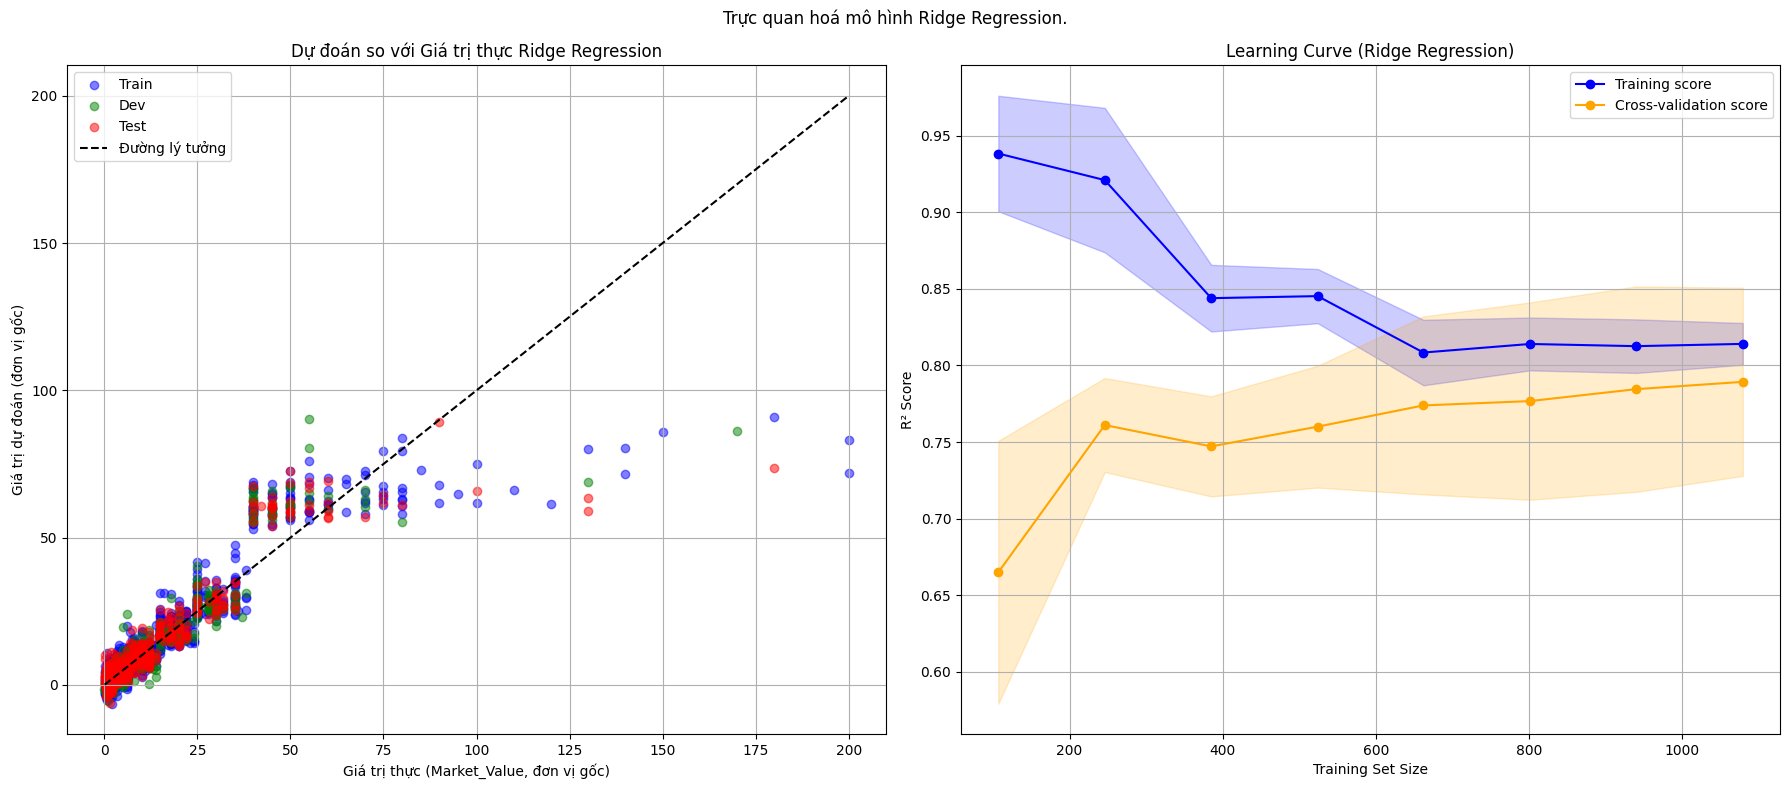

In [4]:
data_rg = data_clean.copy () # Biến data_rg dành cho Ridge Regression

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
'''
KHÔNG SỬ DỤNG: Vì Box-Cox và yeo-johnson không cho ra dự đoán tốt bằng log1p
y_boxcox, lambda_optimal = stats.boxcox(data_clean['Market_Value']): Box-Cox và 
pt = PowerTransformer(method='yeo-johnson')
y = data_clean['Market_Value'].values.reshape(-1, 1)
y_yeo = pt.fit_transform(y)
'''
X = data_rg.drop(columns='Market_Value').values # chuyển sang numpy array
y = data_rg['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Chuẩn hoá X, y
X_scaler, X_train_scaled, X_dev_scaled, X_test_scaled  = module.Standard_X (X_train, X_dev, X_test)
y_scaler, y_train_scaled, y_dev_scaled, y_test_scaled = module.Standard_y (y_train, y_dev, y_test)

# 3. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
ridge = module.Ridge()
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}
grid_search = module.GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)


# 4. Lấy mô hình tốt nhất
best_model_Ridge_Orig = grid_search.best_estimator_
print(f"Tham số tối ưu: alpha = {grid_search.best_params_['alpha']}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")


# 5. Dự đoán
y_train_pred = best_model_Ridge_Orig.predict(X_train_scaled)
y_dev_pred = best_model_Ridge_Orig.predict(X_dev_scaled)
y_test_pred = best_model_Ridge_Orig.predict(X_test_scaled)


# -------- INVERSE YEO: CHỈ SỬ DỤNG NẾU CHUẨN HOÁ MARKET_VALUE BẰNG YEO_JOHNSON ---------
# y_test_pred = pt.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()
# y_dev_pred = pt.inverse_transform(y_dev_pred.reshape(-1, 1)).flatten()
# y_train_pred = pt.inverse_transform(y_train_pred.reshape(-1, 1)).flatten()
# y_train_orig = pt.inverse_transform(y_train.reshape(-1, 1)).flatten()
# y_dev_orig   = pt.inverse_transform(y_dev.reshape(-1, 1)).flatten()
# y_test_orig  = pt.inverse_transform(y_test.reshape(-1, 1)).flatten()

# --------- CHỈ SỬ DỤNG NẾU CHUẨN HOÁ MARKET_VALUE BẰNG BOX-COX -----------
# from scipy.special import inv_boxcox
# y_train_pred = inv_boxcox(y_train_pred, lambda_optimal)
# y_dev_pred = inv_boxcox(y_dev_pred, lambda_optimal)
# y_test_pred = inv_boxcox(y_test_pred, lambda_optimal)
# y_train_orig = inv_boxcox(y_train, lambda_optimal)
# y_dev_orig   = inv_boxcox(y_dev, lambda_optimal)
# y_test_orig  = inv_boxcox(y_test, lambda_optimal)
# y_train_orig = (y_train)
# y_dev_orig   = (y_dev)
# y_test_orig  = (y_test)

y_train_pred, y_dev_pred, y_test_pred = module.inverse_y (y_scaler, y_train_pred, y_dev_pred, y_test_pred)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Ridge Regression', best_model_Ridge_Orig, data_rg)
coef_df = pd.DataFrame({
    'Feature': data_rg.drop ('Market_Value', axis=1).columns,
    'Coefficient': best_model_Ridge_Orig.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop đặc trưng ảnh hưởng mạnh nhất:")
print(coef_df.head(10).to_string(index=False))

# 8. Trực quan hoá 
module.Visualize (best_model_Ridge_Orig, 'Ridge Regression', X_train_scaled, y_train_scaled, y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

## Ridge Regression - IQR

Số lượng mẫu sau khi lọc: 2067
Tham số tối ưu: alpha = 0.001
Best CV MSE (scaled): 0.0512
Kết quả đánh giá mô hình Ridge Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         3.7240    1.9298    0.9542       38.56    1.4099
Dev           3.6106    1.9001    0.9544       35.57    1.4129
Test          3.3452    1.8290    0.9519       34.95    1.3471

Top đặc trưng ảnh hưởng mạnh nhất:
                 Feature  Coefficient
   Club_Group_Upper Tier     0.890128
Club_Group_Mid-High Tier     0.625069
     Club_Group_Mid-Tier     0.338415
   Club_Group_Lower Tier     0.118041
              League_EPL     0.037562
                    Mins     0.025921
                 Assists     0.023030
                     Age    -0.020065
                     PS%     0.019900
           League_Ligue1    -0.018027


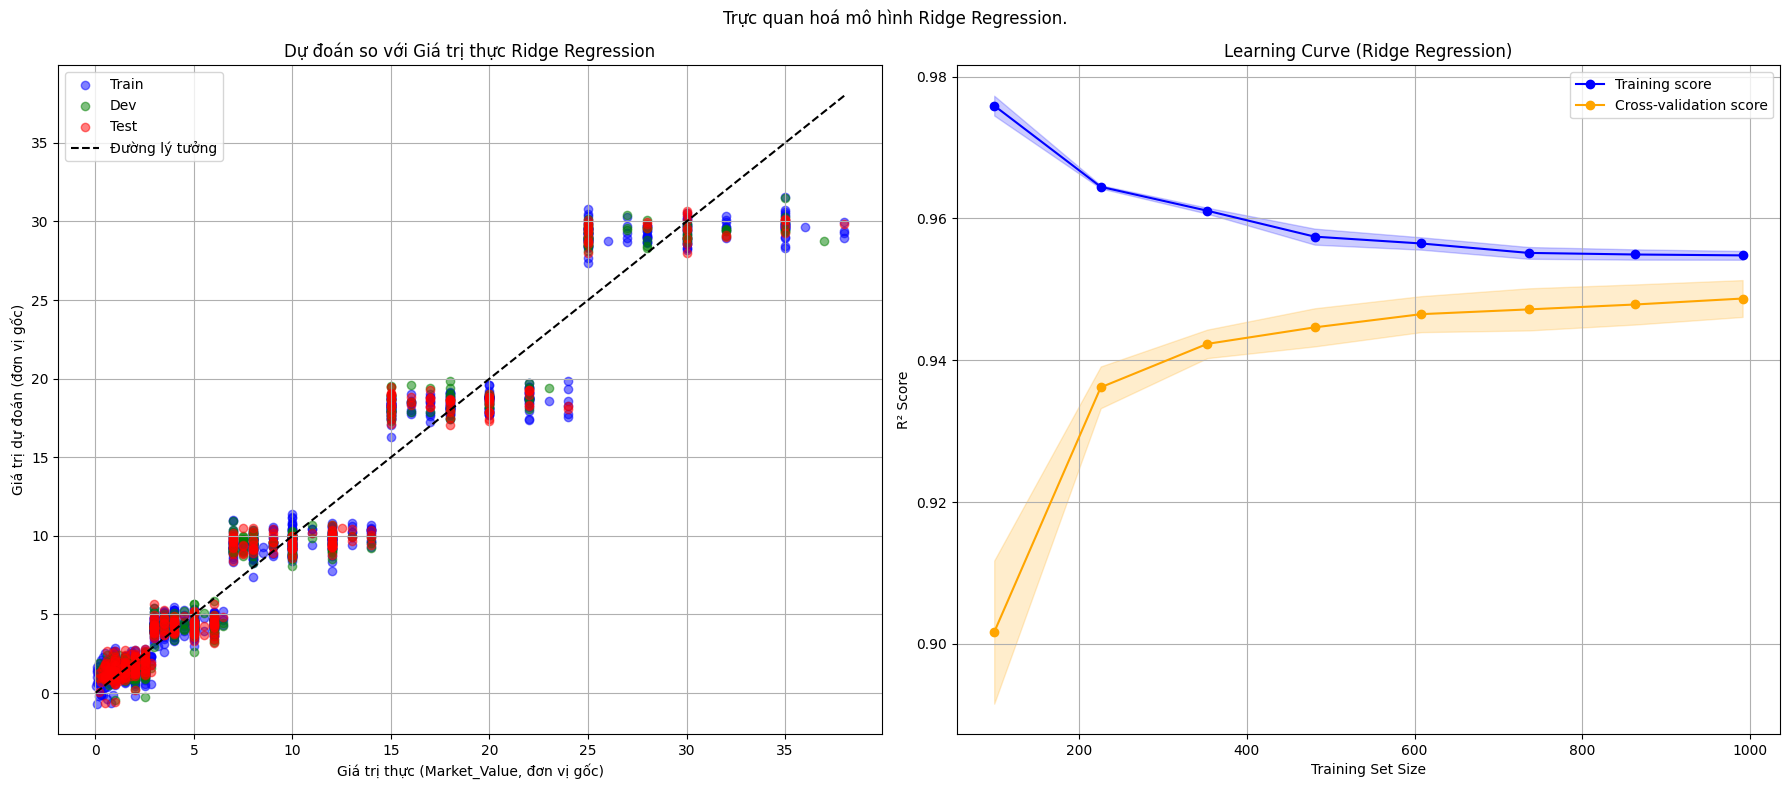

In [5]:
data_rg = data_clean.copy () # Biến data_rg dành cho Ridge Regression
data_rg = module.remove_outliers_iqr (data_rg)
print ('Số lượng mẫu sau khi lọc:', len (data_rg))

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_rg.drop(columns='Market_Value').values # chuyển sang numpy array
y = data_rg['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)


# 2. Chuẩn hoá X, y
X_scaler, X_train_scaled, X_dev_scaled, X_test_scaled  = module.Standard_X (X_train, X_dev, X_test)
y_scaler, y_train_scaled, y_dev_scaled, y_test_scaled = module.Standard_y (y_train, y_dev, y_test)

# 3. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
ridge = Ridge()
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)


# 4. Lấy mô hình tốt nhất
best_model_Ridge_IQR = grid_search.best_estimator_
print(f"Tham số tối ưu: alpha = {grid_search.best_params_['alpha']}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")


# 5. Dự đoán
y_train_pred = best_model_Ridge_IQR.predict(X_train_scaled)
y_dev_pred = best_model_Ridge_IQR.predict(X_dev_scaled)
y_test_pred = best_model_Ridge_IQR.predict(X_test_scaled)

y_train_pred, y_dev_pred, y_test_pred = module.inverse_y (y_scaler, y_train_pred, y_dev_pred, y_test_pred)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Ridge Regression', best_model_Ridge_IQR, data_rg)
coef_df = pd.DataFrame({
    'Feature': data_rg.drop ('Market_Value', axis=1).columns,
    'Coefficient': best_model_Ridge_IQR.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop đặc trưng ảnh hưởng mạnh nhất:")
print(coef_df.head(10).to_string(index=False))

# 8. Trực quan hoá 
module.Visualize (best_model_Ridge_IQR, 'Ridge Regression',X_train_scaled,y_train_scaled, y_train,y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

## Ridge Regression - Winsorizing

Tham số tối ưu: alpha = 0.001
Best CV MSE (scaled): 0.0277
Kết quả đánh giá mô hình Ridge Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         4.6414    2.1544    0.9745       25.84    1.5583
Dev           4.9830    2.2323    0.9724       25.61    1.5923
Test          3.6364    1.9069    0.9805       29.45    1.4176

Top đặc trưng ảnh hưởng mạnh nhất:
                 Feature  Coefficient
     Club_Group_Top Tier     0.873657
   Club_Group_Upper Tier     0.560449
Club_Group_Mid-High Tier     0.394174
     Club_Group_Mid-Tier     0.209723
   Club_Group_Lower Tier     0.072969
              League_EPL     0.032464
                 Assists     0.029249
                     Age    -0.025491
                  Rating     0.022957
                   Goals     0.018113


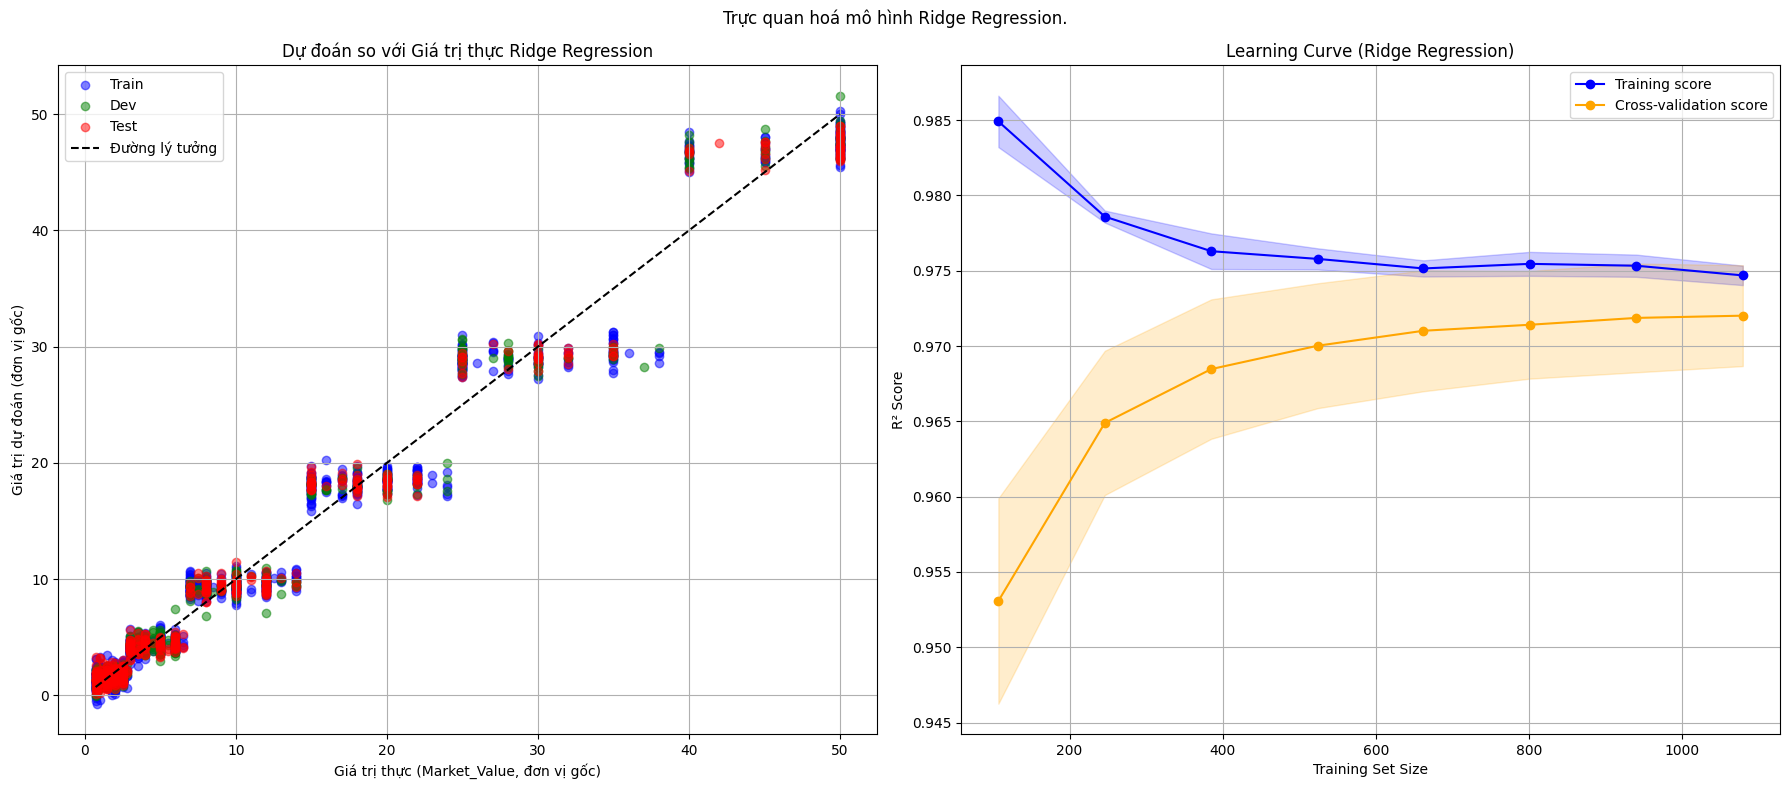

In [6]:
data_rg = data_clean.copy () # Biến data_rg dành cho Ridge Regression
y_winsorized = module.winsorize_data (data_rg['Market_Value'])

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_rg.drop(columns='Market_Value').values # chuyển sang numpy array
y = y_winsorized.values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Chuẩn hoá X, y
X_scaler, X_train_scaled, X_dev_scaled, X_test_scaled  = module.Standard_X (X_train, X_dev, X_test)
y_scaler, y_train_scaled, y_dev_scaled, y_test_scaled = module.Standard_y (y_train, y_dev, y_test)

# 3. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
ridge = Ridge()
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# 4. Lấy mô hình tốt nhất
best_model_Ridge_Win = grid_search.best_estimator_
print(f"Tham số tối ưu: alpha = {grid_search.best_params_['alpha']}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_Ridge_Win.predict(X_train_scaled)
y_dev_pred = best_model_Ridge_Win.predict(X_dev_scaled)
y_test_pred = best_model_Ridge_Win.predict(X_test_scaled)
y_train_pred, y_dev_pred, y_test_pred = module.inverse_y (y_scaler, y_train_pred, y_dev_pred, y_test_pred)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Ridge Regression', best_model_Ridge_Win, data_rg)
coef_df = pd.DataFrame({
    'Feature': data_rg.drop ('Market_Value', axis=1).columns,
    'Coefficient': best_model_Ridge_Win.coef_ 
}).sort_values(by='Coefficient', key=abs, ascending=False)

print("\nTop đặc trưng ảnh hưởng mạnh nhất:")
print(coef_df.head(10).to_string(index=False))

# 8. Trực quan hoá 
module.Visualize (best_model_Ridge_Win, 'Ridge Regression',X_train_scaled, y_train_scaled, y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

In [7]:
from statsmodels.stats.stattools import durbin_watson

# Tính phần dư trên tập Test (hoặc Dev)
residuals = y_test - y_test_pred.ravel() 

# # Áp dụng Durbin-Watson Test
dw_stat = durbin_watson(residuals)

print(f'Durbin-Watson statistic: {dw_stat:.3f}')


Durbin-Watson statistic: 2.089


Đánh giá tổng thể:
Mô hình Ridge với alpha=0.001 cho kết quả rất tốt, chính xác, không bị overfitting vì train/dev/test đều có kết quả rất gần nhau.

Kết quả trên tập dev và test còn tốt hơn hoặc rất sát với train → mô hình có khả năng tổng quát hóa cao.

Mô hình này đủ dùng cho ứng dụng thực tế, có thể tiếp tục tinh chỉnh hoặc thêm dữ liệu để cải thiện hơn.

# Support Vector Machine

### SVM - Original

Tham số tối ưu: {'C': 100, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV MSE (scaled): 0.2858
Kết quả đánh giá mô hình Support Vector Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         0.0370    0.1923    0.9999        7.14    0.1901
Dev          85.9986    9.2735    0.7005      109.11    3.7642
Test         75.7085    8.7011    0.7908      120.46    3.7910


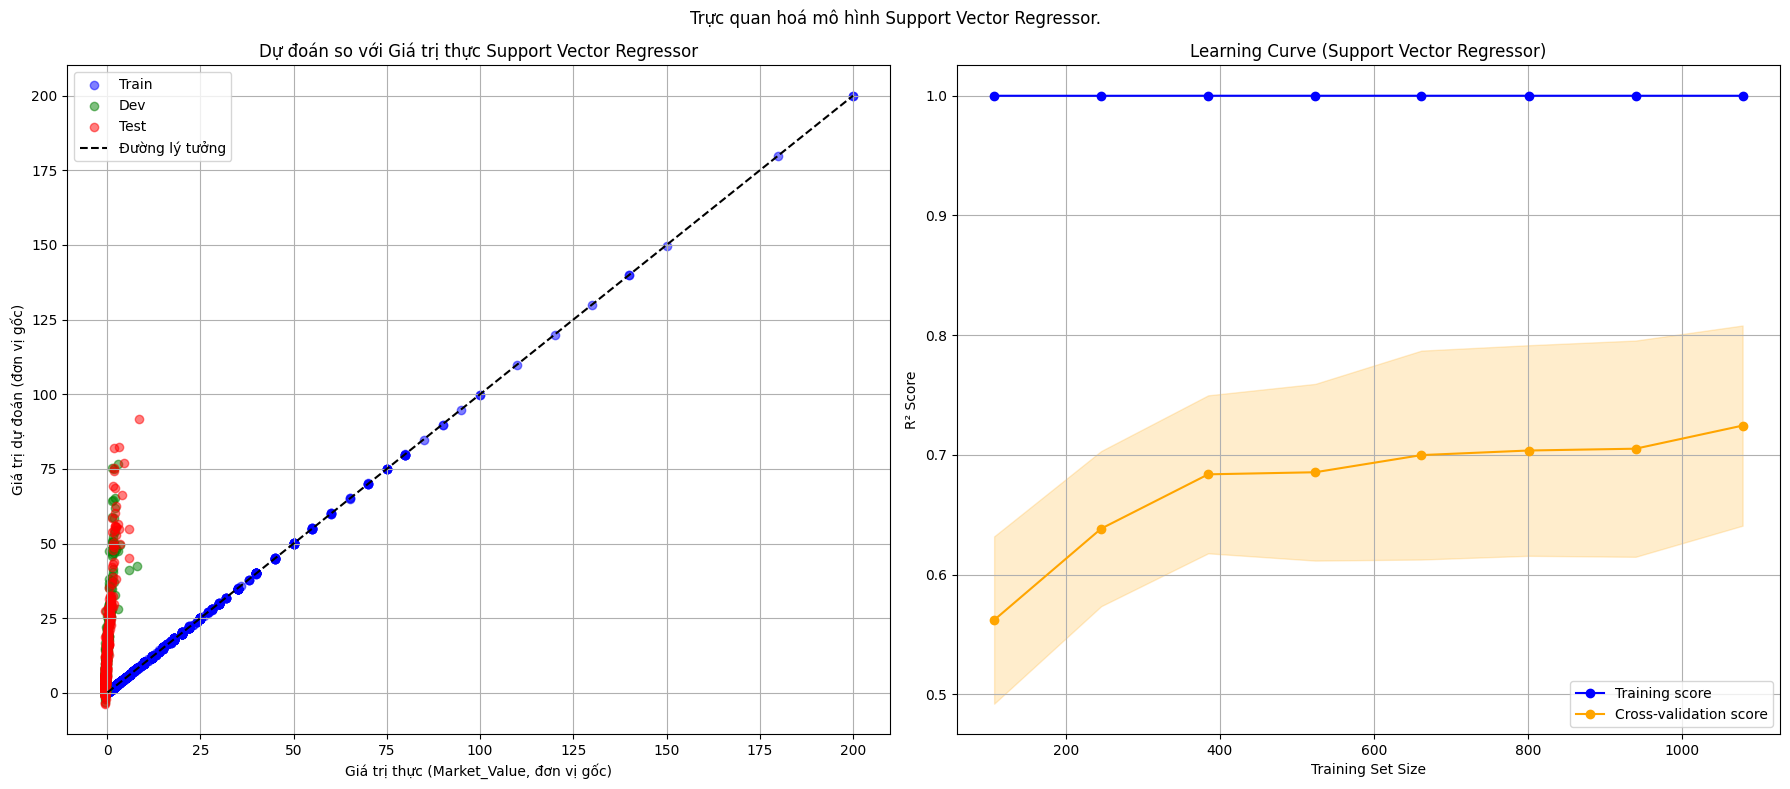

In [8]:
data_svm = data_clean.copy ()

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_svm.drop(columns='Market_Value').values
y = data_svm['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Chuẩn hoá X, y
X_scaler, X_train_scaled, X_dev_scaled, X_test_scaled  = module.Standard_X (X_train, X_dev, X_test)
y_scaler, y_train_scaled, y_dev_scaled, y_test_scaled = module.Standard_y (y_train, y_dev, y_test)

# 3. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
svr = SVR()
svm_param_grid = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(svr, svm_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# 4. Lấy mô hình tốt nhất
best_model_SVM_Orig = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_SVM_Orig.predict(X_train_scaled)
y_dev_pred = best_model_SVM_Orig.predict(X_dev_scaled)
y_test_pred = best_model_SVM_Orig.predict(X_test_scaled)

y_train_pred, y_dev_pred, y_test_pred = module.inverse_y (y_scaler, y_train_pred, y_dev_pred, y_test_pred)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Support Vector Regressor', best_model_SVM_Orig, data_svm)

# 8. Trực quan hoá 
module.Visualize (best_model_SVM_Orig, 'Support Vector Regressor', X_train_scaled, y_train_scaled,y_train, y_dev_scaled, y_test_scaled, y_train_pred, y_dev_pred, y_test_pred)

## SVM - IQR

Số lượng mẫu sau khi lọc: 2067
Tham số tối ưu: {'C': 10, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV MSE (scaled): 0.1236
Kết quả đánh giá mô hình Support Vector Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         0.6274    0.7921    0.9923       34.04    0.7457
Dev           7.9441    2.8185    0.8998       66.02    2.0372
Test          7.4993    2.7385    0.8922       70.79    1.9519


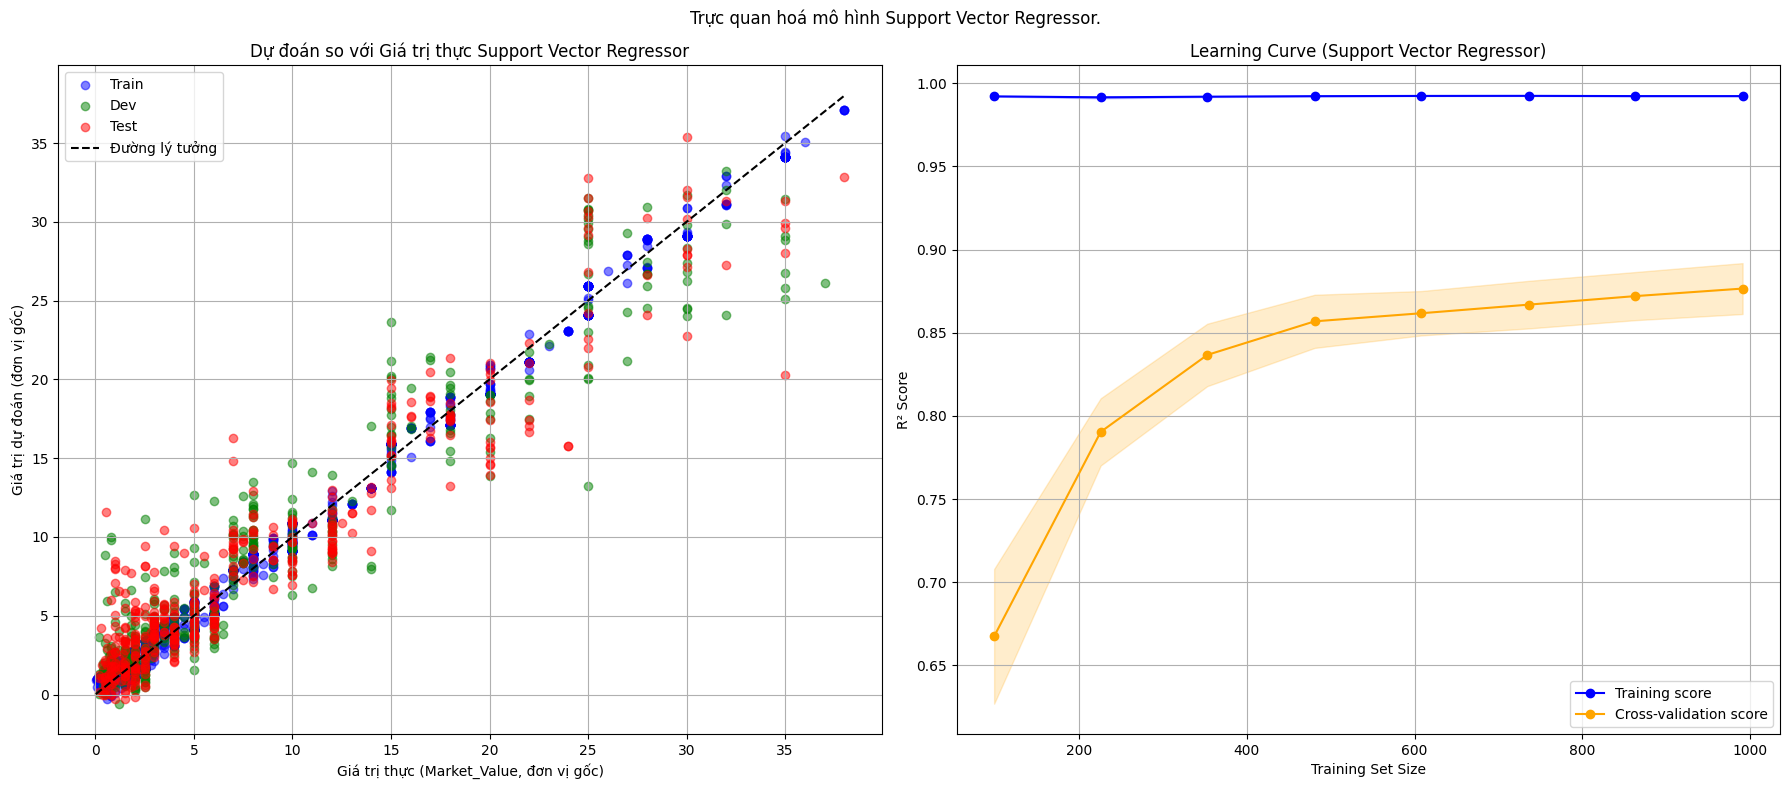

In [12]:
data_svm = data_clean.copy ()
data_svm = module.remove_outliers_iqr (data_svm)
print ('Số lượng mẫu sau khi lọc:', len (data_svm))

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_svm.drop(columns='Market_Value').values
y = data_svm['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Chuẩn hoá X, y
X_scaler, X_train_scaled, X_dev_scaled, X_test_scaled  = module.Standard_X (X_train, X_dev, X_test)
y_scaler, y_train_scaled, y_dev_scaled, y_test_scaled = module.Standard_y (y_train, y_dev, y_test)

# 3. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
svr = SVR()
svm_param_grid = {
    'kernel': ['rbf'],
    'C': [0.01, 0.1, 1, 10, 100],
    'epsilon': [0.1, 0.2],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(svr, svm_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# 4. Lấy mô hình tốt nhất
best_model_SVM_IQR = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_SVM_IQR.predict(X_train_scaled)
y_dev_pred = best_model_SVM_IQR.predict(X_dev_scaled)
y_test_pred = best_model_SVM_IQR.predict(X_test_scaled)

y_train_pred, y_dev_pred, y_test_pred = module.inverse_y (y_scaler, y_train_pred, y_dev_pred, y_test_pred)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Support Vector Regressor', best_model_SVM_IQR, data_svm)

# 8. Trực quan hoá 
module.Visualize (best_model_SVM_IQR, 'Support Vector Regressor', X_train_scaled, y_train_scaled,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

## SVM - Winsorizing

Tham số tối ưu: {'C': 10, 'epsilon': 0.01, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV MSE (scaled): 0.0901
Kết quả đánh giá mô hình Support Vector Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         0.0190    0.1379    0.9999        4.18    0.1337
Dev          16.4905    4.0609    0.9086       52.94    2.5634
Test         13.1884    3.6316    0.9291       66.22    2.4353


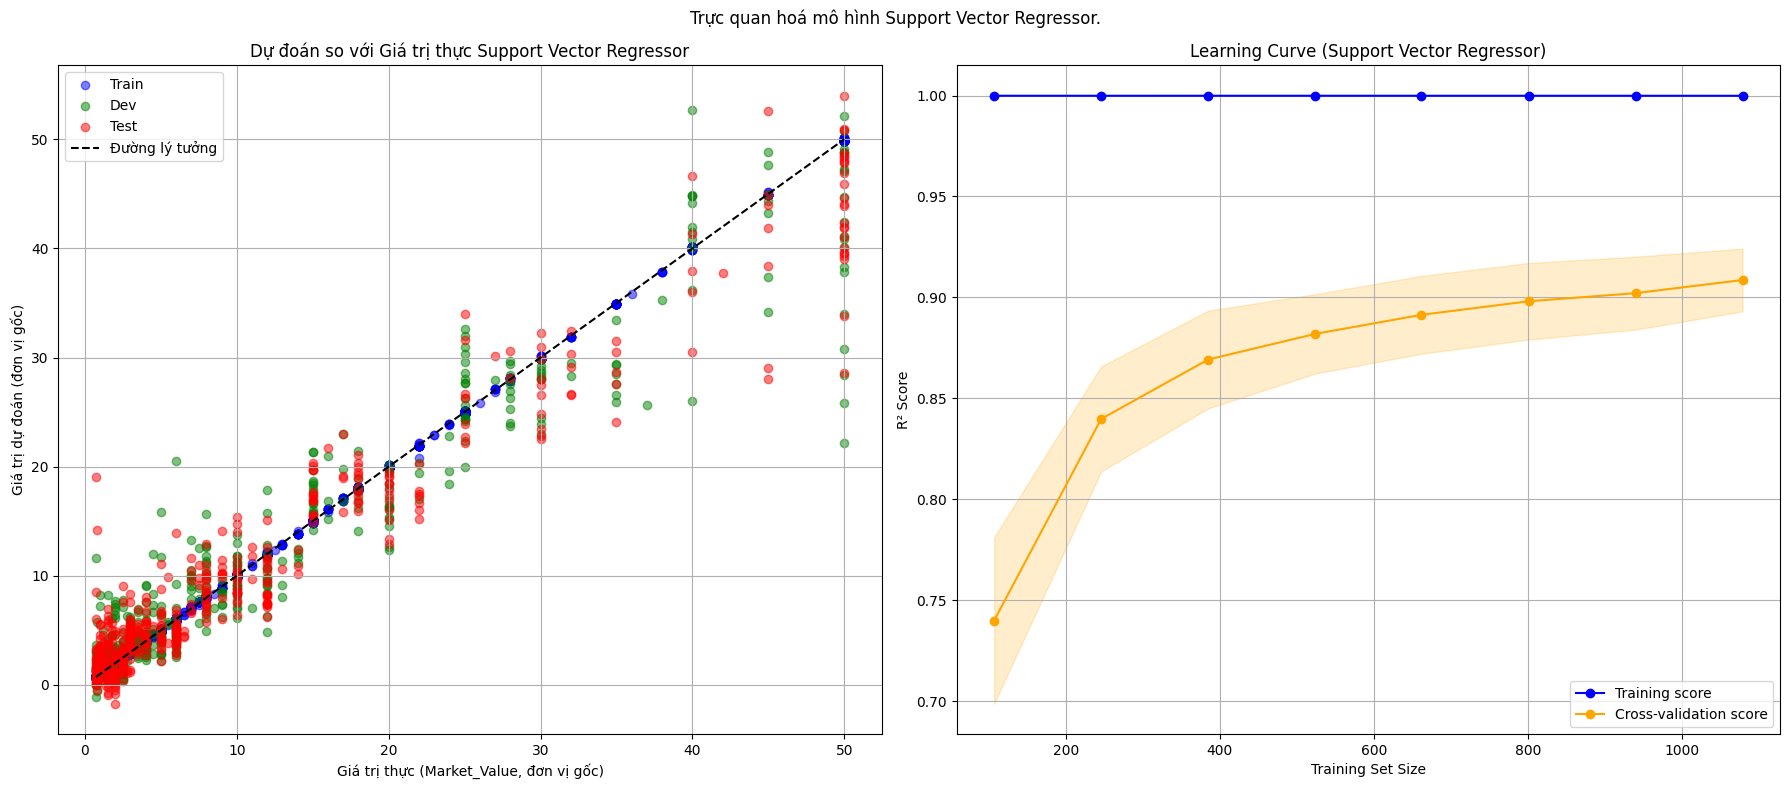

In [10]:
data_svm = data_clean.copy ()
y_winsorized = module.winsorize_data (data_svm['Market_Value'])

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_svm.drop(columns='Market_Value').values
y = y_winsorized
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Chuẩn hoá X, y
X_scaler, X_train_scaled, X_dev_scaled, X_test_scaled  = module.Standard_X (X_train, X_dev, X_test)
y_scaler, y_train_scaled, y_dev_scaled, y_test_scaled = module.Standard_y (y_train, y_dev, y_test)

# 3. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
svr = SVR()
svm_param_grid = {
    'kernel': ['rbf'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}
grid_search = GridSearchCV(svr, svm_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_scaled, y_train_scaled)

# 4. Lấy mô hình tốt nhất
best_model_SVM_Orig = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_SVM_Orig.predict(X_train_scaled)
y_dev_pred = best_model_SVM_Orig.predict(X_dev_scaled)
y_test_pred = best_model_SVM_Orig.predict(X_test_scaled)

y_train_pred, y_dev_pred, y_test_pred = module.inverse_y (y_scaler, y_train_pred, y_dev_pred, y_test_pred)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Support Vector Regressor', best_model_SVM_Orig, data_svm)

# 8. Trực quan hoá 
module.Visualize (best_model_SVM_Orig, 'Support Vector Regressor', X_train_scaled, y_train_scaled,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

In [13]:
from statsmodels.stats.stattools import durbin_watson

# Tính phần dư trên tập Test (hoặc Dev)
residuals = y_test - y_test_pred.ravel() 

# # Áp dụng Durbin-Watson Test
dw_stat = durbin_watson(residuals)

print(f'Durbin-Watson statistic: {dw_stat:.3f}')


Durbin-Watson statistic: 2.004


# Random Forest

## Random Forest - Original

Tham số tối ưu: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.5, 'max_depth': 20}
Best CV MSE (scaled): 63.0181
Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train        27.8931    5.2814    0.9266       28.77    1.8166
Dev          47.2464    6.8736    0.8354       41.74    2.6140
Test         64.4073    8.0254    0.8220       54.12    2.6052


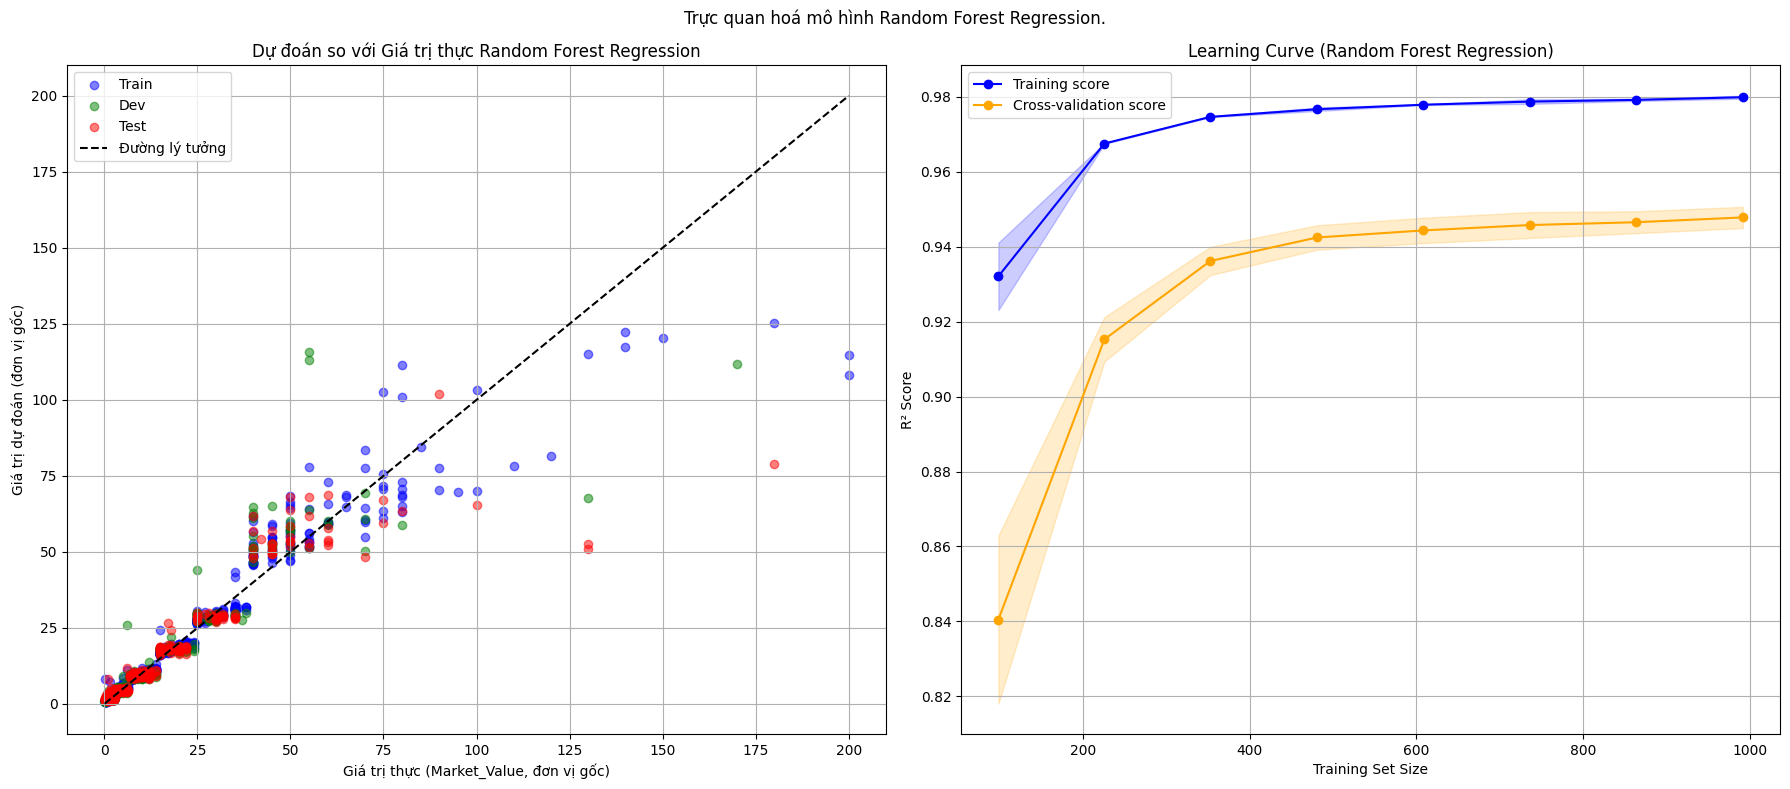

In [14]:
data_rf = data_clean.copy () # Biến data_rg dành cho Ridge Regression

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_rf.drop(columns='Market_Value').values # chuyển sang numpy array
y = data_rf ['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
rf = RandomForestRegressor(random_state = 32)
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
}
# grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
# grid_search.fit(X_train, y_train)
random_search = RandomizedSearchCV(
    rf, rf_param_grid,
    n_iter=40,  # Thử 30 tổ hợp ngẫu nhiên
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)

# 3. Lấy mô hình tốt nhất
best_model_RF_Orig = random_search.best_estimator_
print(f"Tham số tối ưu: {random_search.best_params_}")
print(f"Best CV MSE (scaled): {-random_search.best_score_:.4f}")


# 4. Dự đoán
y_train_pred = best_model_RF_Orig.predict(X_train)
y_dev_pred = best_model_RF_Orig.predict(X_dev)
y_test_pred = best_model_RF_Orig.predict(X_test)


# 5. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_Orig, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_Orig, 'Random Forest Regression',X_train_scaled, y_train_scaled,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

## Random Forest - IQR

### None Feature Importance

Số lượng mẫu sau khi lọc: 2067
Tham số tối ưu: {'max_depth': 5, 'min_samples_leaf': 8, 'min_samples_split': 5, 'n_estimators': 100}
Best CV MSE (scaled): 4.1588
Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.9321    1.7123    0.9640       38.54    1.2972
Dev           4.0110    2.0027    0.9494       33.91    1.4412
Test          3.2452    1.8015    0.9533       35.12    1.3070


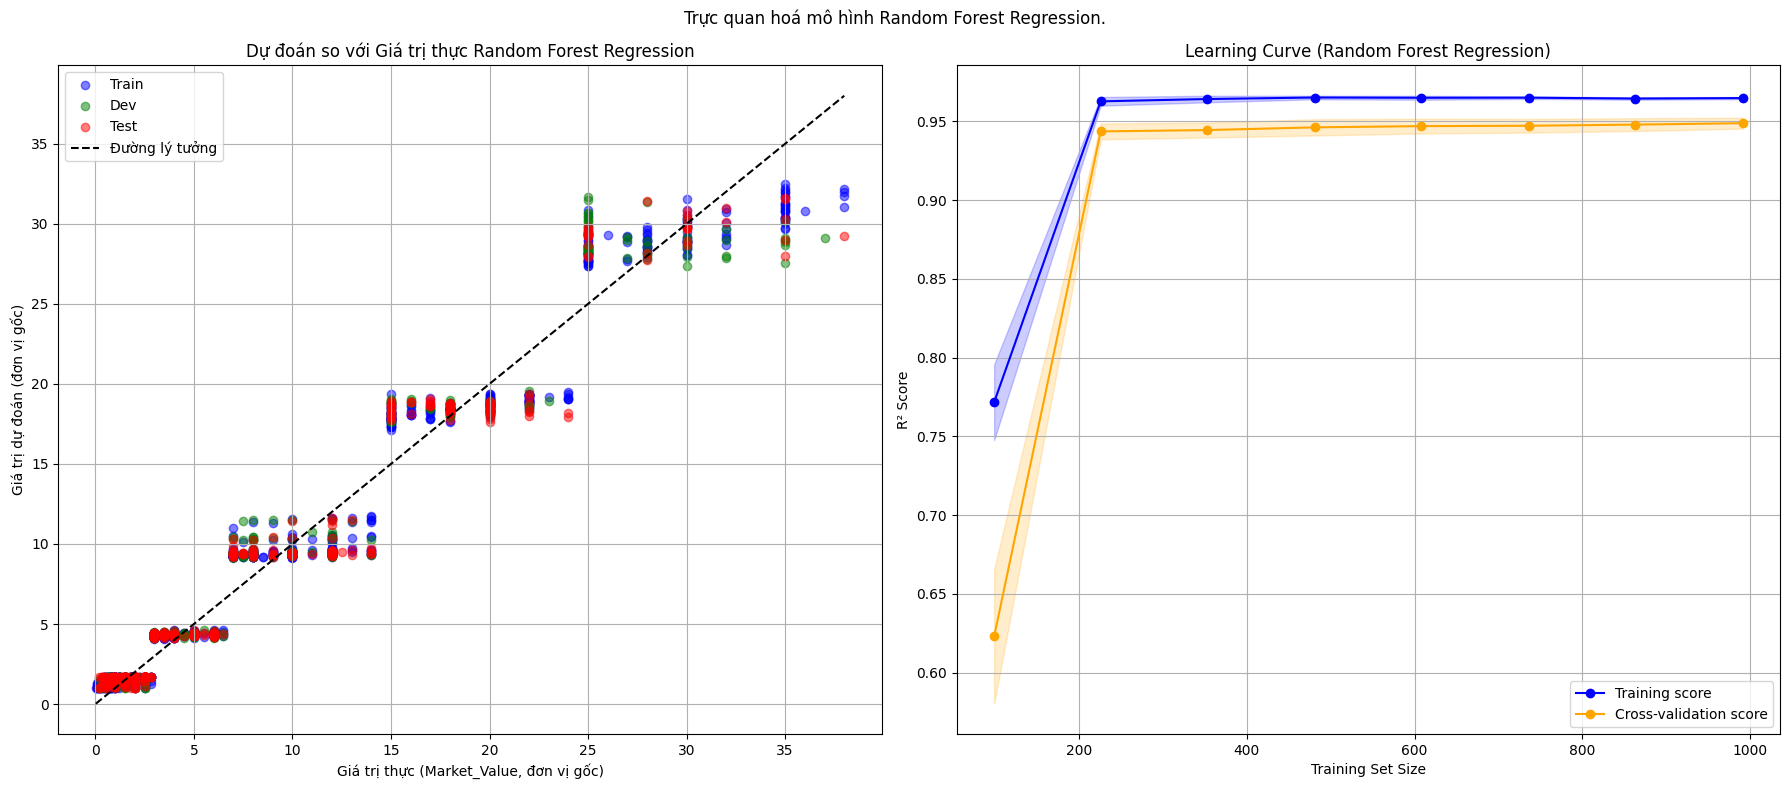

In [16]:
data_rf = data_clean.copy ()
data_rf = module.remove_outliers_iqr (data_rf)
print ('Số lượng mẫu sau khi lọc:', len (data_rf))

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_rf.drop(columns='Market_Value').values # chuyển sang numpy array
y = data_rf ['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
rf = RandomForestRegressor(random_state = 32)
rf_param_grid = {
    # 'n_estimators': [100, 300],
    # 'max_depth': [5, 10, 20],
    # 'min_samples_split': [2, 5, 10],
    # 'min_samples_leaf': [1, 2, 4],
    # 'max_features': ['sqrt', 'log2', 0.5]
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 4, 8]
}
grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train, y_train)
# random_search = RandomizedSearchCV(
#     rf, rf_param_grid,
#     n_iter=40,  # Thử 40 tổ hợp ngẫu nhiên
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42
# )
# random_search.fit(X_train, y_train)

# 3. Lấy mô hình tốt nhất
best_model_RF_IQR = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")


# 4. Dự đoán
y_train_pred = best_model_RF_IQR.predict(X_train)
y_dev_pred = best_model_RF_IQR.predict(X_dev)
y_test_pred = best_model_RF_IQR.predict(X_test)


# 5. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_IQR, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_IQR, 'Random Forest Regression', X_train, y_train,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

### Visualize Feature Importance

Độ quan trọng của đặc trưng (Feature Importance):
                     Feature  Importance
0      Club_Group_Upper Tier    0.581739
1   Club_Group_Mid-High Tier    0.298361
2        Club_Group_Mid-Tier    0.090661
3      Club_Group_Lower Tier    0.013744
4                        PS%    0.002141
5                     Height    0.001437
6                       Mins    0.001346
7                    Sub_app    0.001218
8                        Age    0.000694
9                     Rating    0.000649
10                    TotClr    0.000649
11                   Assists    0.000639
12                    TotInt    0.000622
13                     Fouls    0.000539
14               Months_left    0.000520


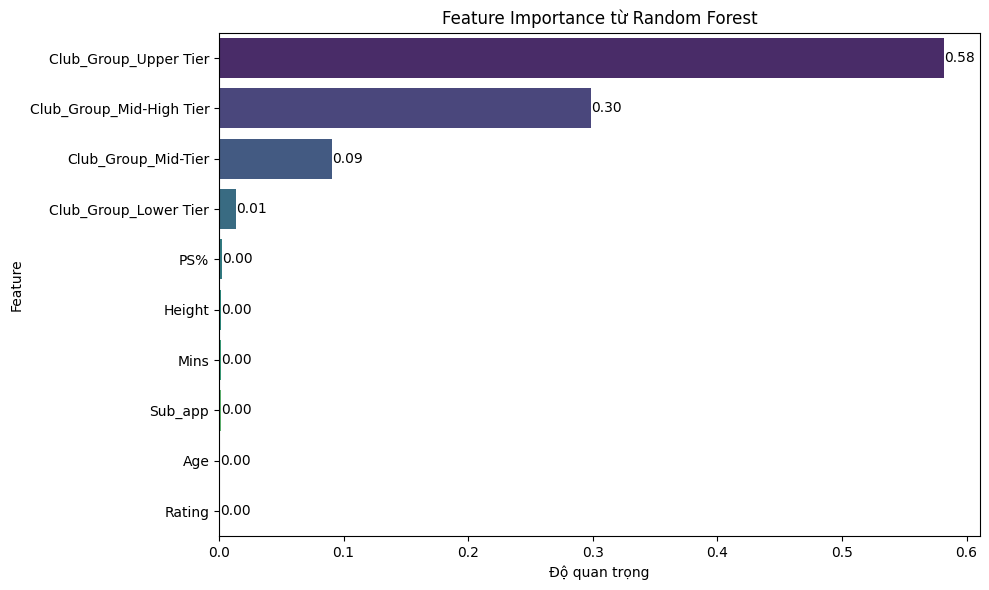

In [17]:
feature_importance = pd.DataFrame({
    'Feature': data_rf.drop ('Market_Value', axis=1).columns,
    'Importance': best_model_RF_IQR.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index ().drop ('index', axis=1)

print("Độ quan trọng của đặc trưng (Feature Importance):")
print (feature_importance.head (15))

top_10 = feature_importance[:10]
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature',data=top_10, palette="viridis")
plt.title("Feature Importance từ Random Forest")
plt.xlabel("Độ quan trọng")
plt.ylabel("Feature")
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 1e-4,                 
        p.get_y() + p.get_height()/2, 
        f"{width:.2f}",                
        va='center'
    )
plt.tight_layout()
plt.show()

### IQR - New Model - Feature Importance

Đặc trưng được chọn: ['Age', 'Height', 'Months_left', 'Sub_app', 'Mins', 'Goals', 'Assists', 'PS%', 'Rating', 'BlkSh', 'BlkPs', 'TotClr', 'Fouled', 'Fouls', 'TotInt', 'UnTch', 'Dispo', 'Card', 'League_EPL', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 45
Số đặc trưng sau khi chọn: 23
Tham số tối ưu: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best CV MSE (scaled): 4.1549
Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         0.8113    0.9007    0.9900       18.50    0.6439
Dev           3.9164    1.9790    0.9506       34.37    1.4300
Test          3.2689    1.8080    0.9530       34.54    1.2896


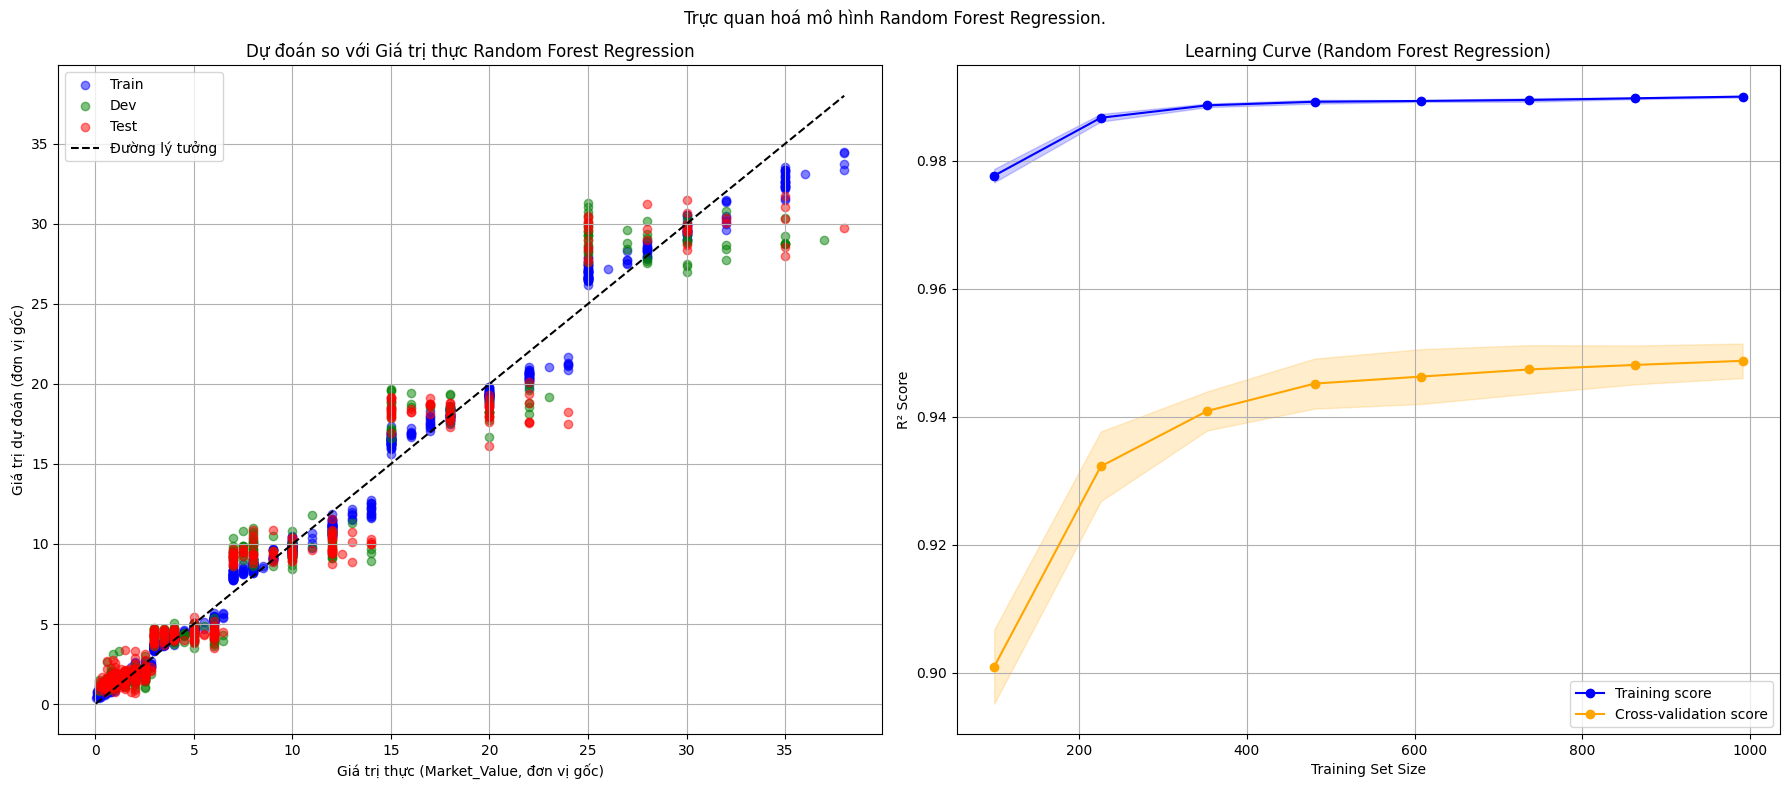

In [18]:
# 1. Chọn các Features tốt nhất bằng SelectFromModel
selector = SelectFromModel(best_model_RF_IQR, threshold="median")  # Hoặc threshold="mean", hoặc giá trị cụ thể như 0.01
selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_dev_sel   = selector.transform(X_dev)
X_test_sel  = selector.transform(X_test)

# 2. Lấy danh sách đặc trưng được chọn
selected_features = data_rf.drop ('Market_Value',axis=1).columns[selector.get_support()].tolist()
print(f"Đặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

# -------- HUẤN LUYỆN LẠI MODEL MỚI ----------
# 3. Tìm bộ tham số tối ưu bằng RandomizedSearchCV
rf = RandomForestRegressor(random_state= 32)
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
    # 'n_estimators': [50, 100],
    # 'max_depth': [5, 10, 15],
    # 'min_samples_split': [5, 10, 20],
    # 'min_samples_leaf': [2, 4, 8]
}
grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_sel, y_train)

# 4. Lấy bộ hyperparameter tối ưu
best_model_RF_IQR_2 = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_RF_IQR_2.predict(X_train_sel)
y_dev_pred = best_model_RF_IQR_2.predict(X_dev_sel)
y_test_pred = best_model_RF_IQR_2.predict(X_test_sel)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_IQR_2, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_IQR_2, 'Random Forest Regression', X_train_sel,y_train, y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

### IQR - Reuse Model - Feature Importance

Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.9418    1.7152    0.9638       38.53    1.2957
Dev           3.9798    1.9949    0.9498       33.92    1.4406
Test          3.2906    1.8140    0.9527       35.15    1.3143


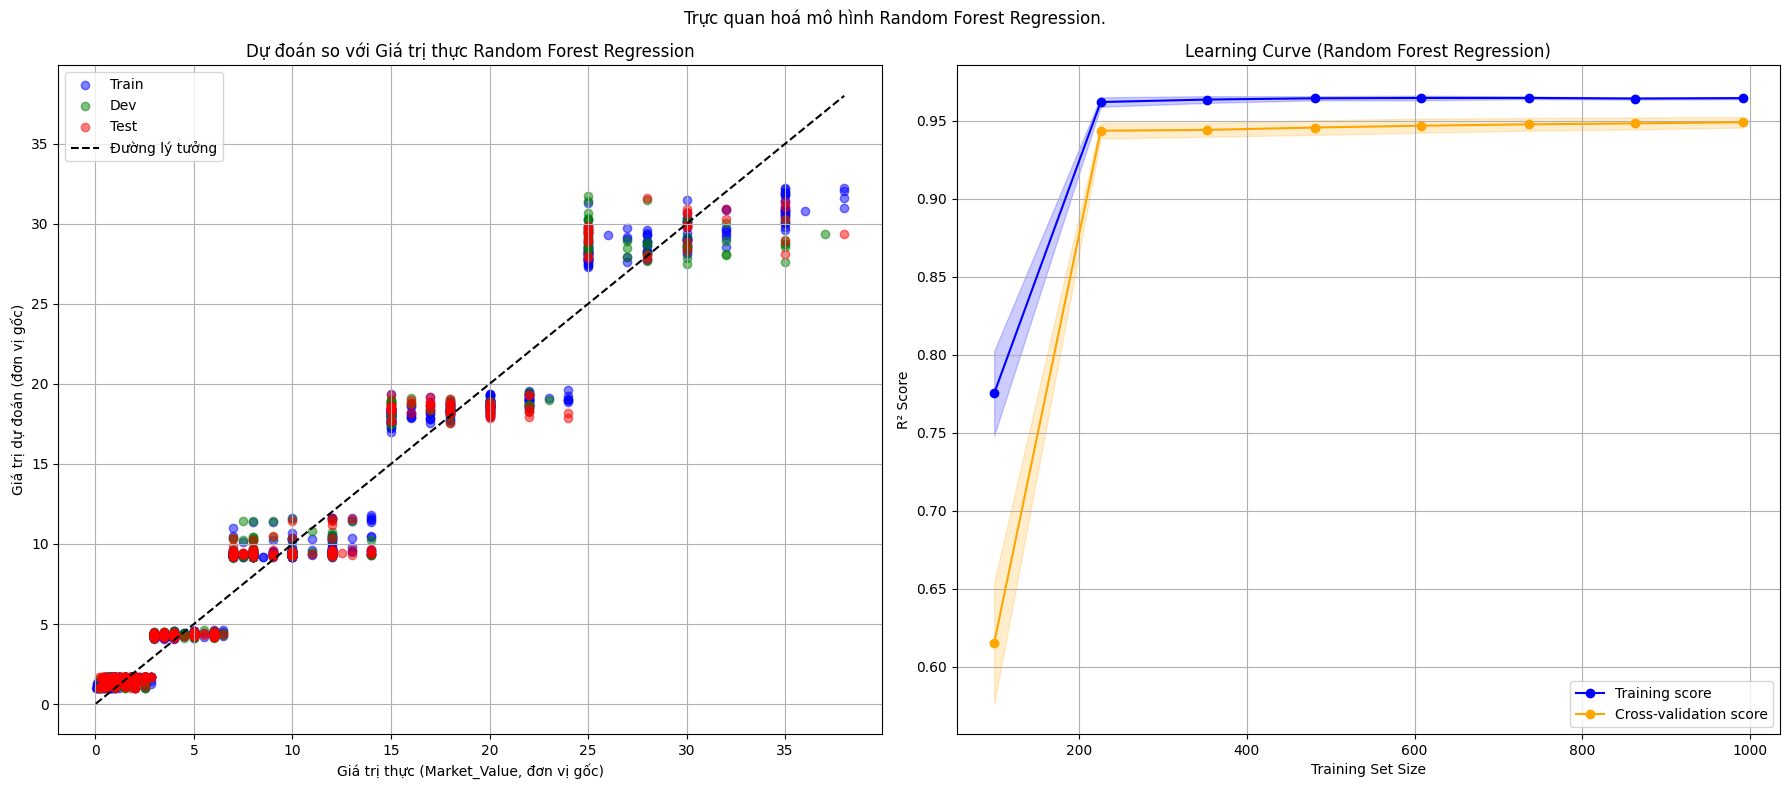

In [20]:
best_model_RF_IQR.fit (X_train_sel, y_train)

y_train_pred = best_model_RF_IQR.predict(X_train_sel)
y_dev_pred = best_model_RF_IQR.predict(X_dev_sel)
y_test_pred = best_model_RF_IQR.predict(X_test_sel)

# 5. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_IQR, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_IQR, 'Random Forest Regression', X_train_sel,y_train, y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

## Random Forest bằng Winsorizing

### None Feature Importance

Tham số tối ưu: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}
Best CV MSE (scaled): 5.3567
Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         1.9849    1.4089    0.9891       16.79    0.9912
Dev           4.7730    2.1847    0.9735       25.69    1.5447
Test          3.7904    1.9469    0.9796       31.02    1.4390


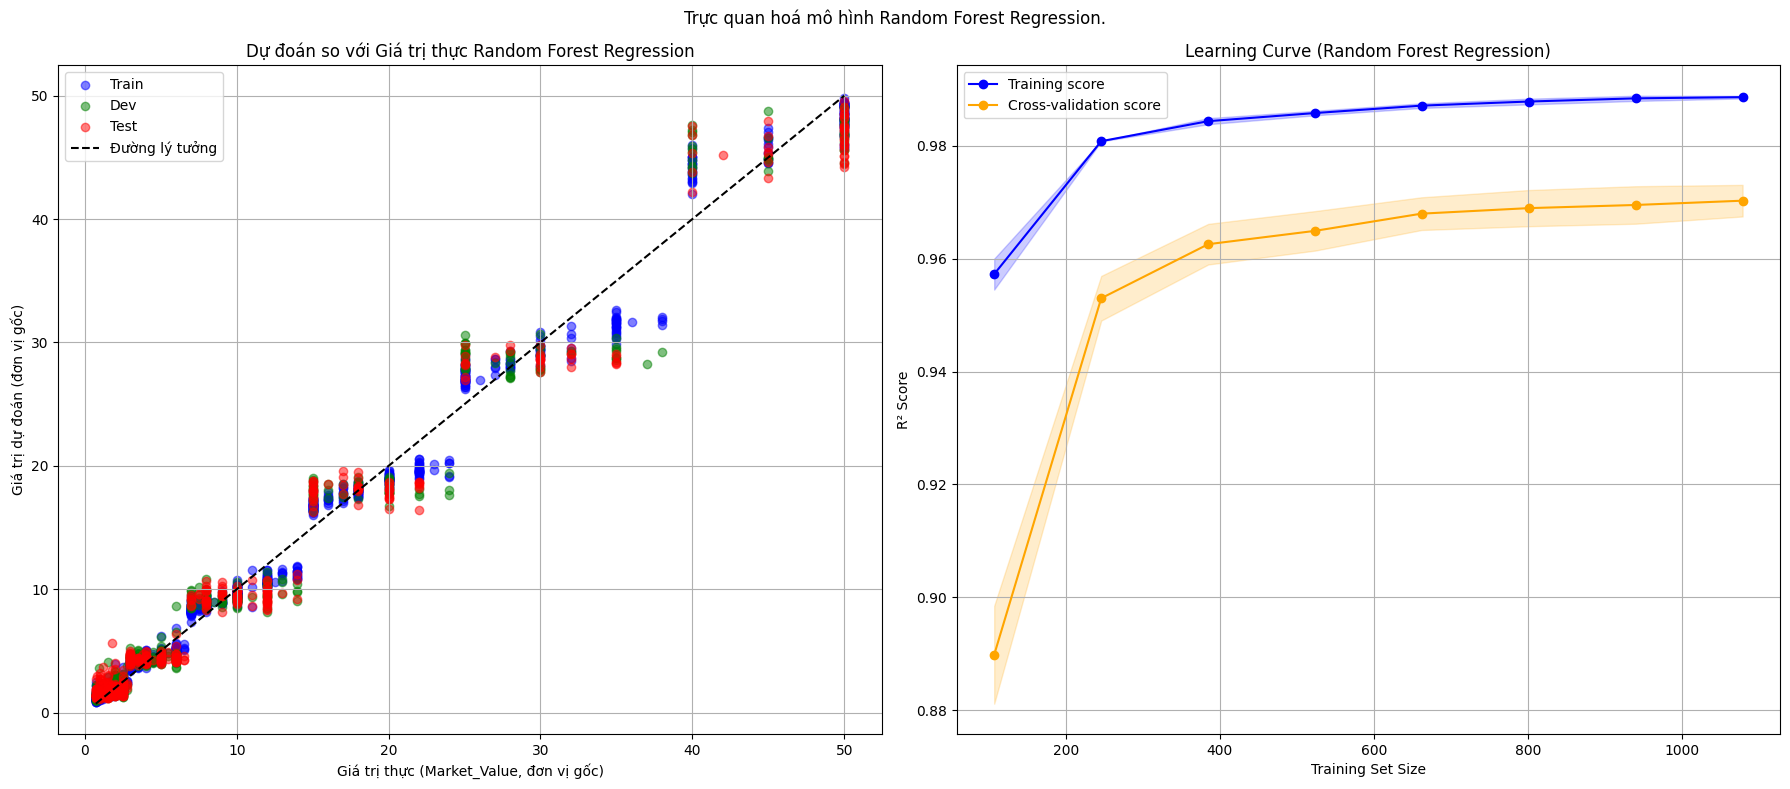

In [ ]:
data_rf = data_clean.copy () # Biến data_rg dành cho Ridge Regression
y_winsorized = module.winsorize_data (data_rf['Market_Value'])

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_rf.drop(columns='Market_Value').values # chuyển sang numpy array
y = y_winsorized
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 2. Tìm bộ siêu tham số tối ưu bằng GridSearchCV
rf = RandomForestRegressor(random_state = 32)
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5]
    # 'n_estimators': [50, 100],
    # 'max_depth': [5, 10, 15],
    # 'min_samples_split': [5, 10, 20],
    # 'min_samples_leaf': [2, 4, 8]
}
grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train, y_train)
# random_search = RandomizedSearchCV(
#     rf, rf_param_grid,
#     n_iter=40,  # Thử 40 tổ hợp ngẫu nhiên
#     cv=5,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     random_state=42
# )
# random_search.fit(X_train, y_train)

# 3. Lấy mô hình tốt nhất
best_model_RF_Win = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")


# 4. Dự đoán
y_train_pred = best_model_RF_Win.predict(X_train)
y_dev_pred = best_model_RF_Win.predict(X_dev)
y_test_pred = best_model_RF_Win.predict(X_test)


# 5. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_Win, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_Win, 'Random Forest Regression', X_train, y_train, y_train, y_train_pred, y_dev_pred, y_test_pred)

### Visualize Feature Importance

Độ quan trọng của đặc trưng (Feature Importance):
                     Feature  Importance
0        Club_Group_Top Tier    0.496582
1      Club_Group_Upper Tier    0.192858
2   Club_Group_Mid-High Tier    0.086688
3                     Rating    0.066710
4        Club_Group_Mid-Tier    0.029942
5                 League_EPL    0.022803
6                    Assists    0.017830
7                Months_left    0.016301
8                      Goals    0.011084
9                        Age    0.010596
10                      MotM    0.009763
11     Club_Group_Lower Tier    0.009661
12                      Mins    0.006745
13                       PS%    0.003161
14                     Dispo    0.002161


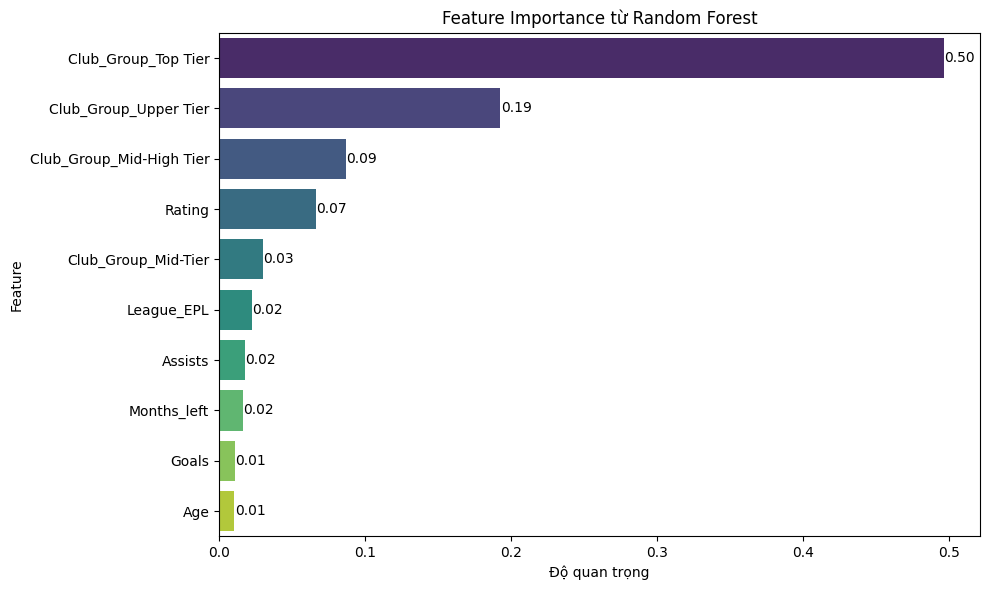

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': data_rf.drop ('Market_Value', axis=1).columns,
    'Importance': best_model_RF_Win.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index ().drop ('index', axis=1)

print("Độ quan trọng của đặc trưng (Feature Importance):")
print (feature_importance.head (15))

top_10 = feature_importance[:10]
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature',data=top_10, palette="viridis")
plt.title("Feature Importance từ Random Forest")
plt.xlabel("Độ quan trọng")
plt.ylabel("Feature")
for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 1e-4,                 
        p.get_y() + p.get_height()/2, 
        f"{width:.2f}",                
        va='center'
    )
plt.tight_layout()
plt.show()

### Winsorizing - New Model - Feature Importance

Đặc trưng được chọn: ['Age', 'Height', 'Months_left', 'Sub_app', 'Mins', 'Goals', 'Assists', 'PS%', 'MotM', 'Rating', 'BlkPs', 'TotClr', 'Fouled', 'Fouls', 'PAGs', 'UnTch', 'Dispo', 'Card', 'League_EPL', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 47
Số đặc trưng sau khi chọn: 24
Tham số tối ưu: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV MSE (scaled): 5.3184
Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         1.7382    1.3184    0.9904       20.63    1.0041
Dev           4.7501    2.1795    0.9737       25.60    1.5283
Test          3.8327    1.9577    0.9794       31.65    1.4499


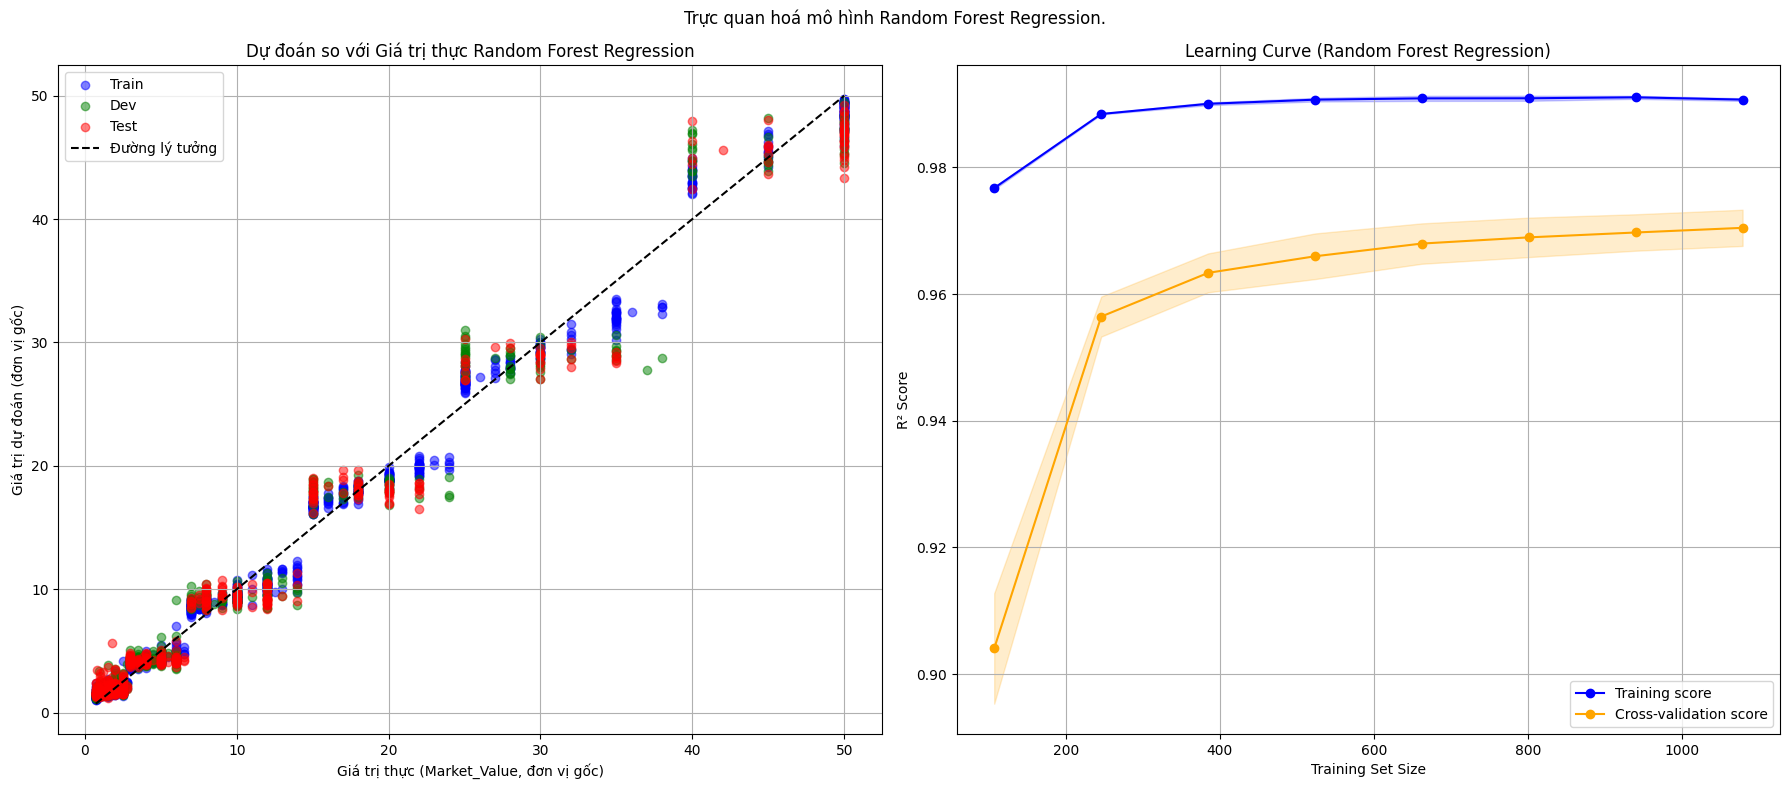

In [ ]:
# 1. Chọn các Features tốt nhất bằng SelectFromModel
selector = SelectFromModel(best_model_RF_Win, threshold="median")  # Hoặc threshold="mean", hoặc giá trị cụ thể như 0.01
selector.fit(X_train, y_train)

X_train_sel = selector.transform(X_train)
X_dev_sel   = selector.transform(X_dev)
X_test_sel  = selector.transform(X_test)

# 2. Lấy danh sách đặc trưng được chọn
selected_features = data_rf.drop ('Market_Value',axis=1).columns[selector.get_support()].tolist()
print(f"Đặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

# -------- HUẤN LUYỆN LẠI MODEL MỚI ----------
# 3. Tìm bộ tham số tối ưu bằng RandomizedSearchCV
rf = RandomForestRegressor(random_state= 32)
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5]
    # 'n_estimators': [50, 100],
    # 'max_depth': [5, 10, 15],
    # 'min_samples_split': [5, 10, 20],
    # 'min_samples_leaf': [2, 4, 8]
}
grid_search = GridSearchCV(rf, rf_param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)
grid_search.fit(X_train_sel, y_train)

# 4. Lấy bộ hyperparameter tối ưu
best_model_RF_Win_2 = grid_search.best_estimator_
print(f"Tham số tối ưu: {grid_search.best_params_}")
print(f"Best CV MSE (scaled): {-grid_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_RF_Win_2.predict(X_train_sel)
y_dev_pred = best_model_RF_Win_2.predict(X_dev_sel)
y_test_pred = best_model_RF_Win_2.predict(X_test_sel)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_Win_2, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_Win_2, 'Random Forest Regression', X_train_sel, y_train, y_train, y_train_pred, y_dev_pred, y_test_pred)

### Winsorizing - Reuse Model - Feature Importance

Kết quả đánh giá mô hình Random Forest Regression với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.0535    1.4330    0.9887       16.95    1.0076
Dev           4.8459    2.2014    0.9731       24.54    1.5347
Test          3.8097    1.9519    0.9795       30.74    1.4433


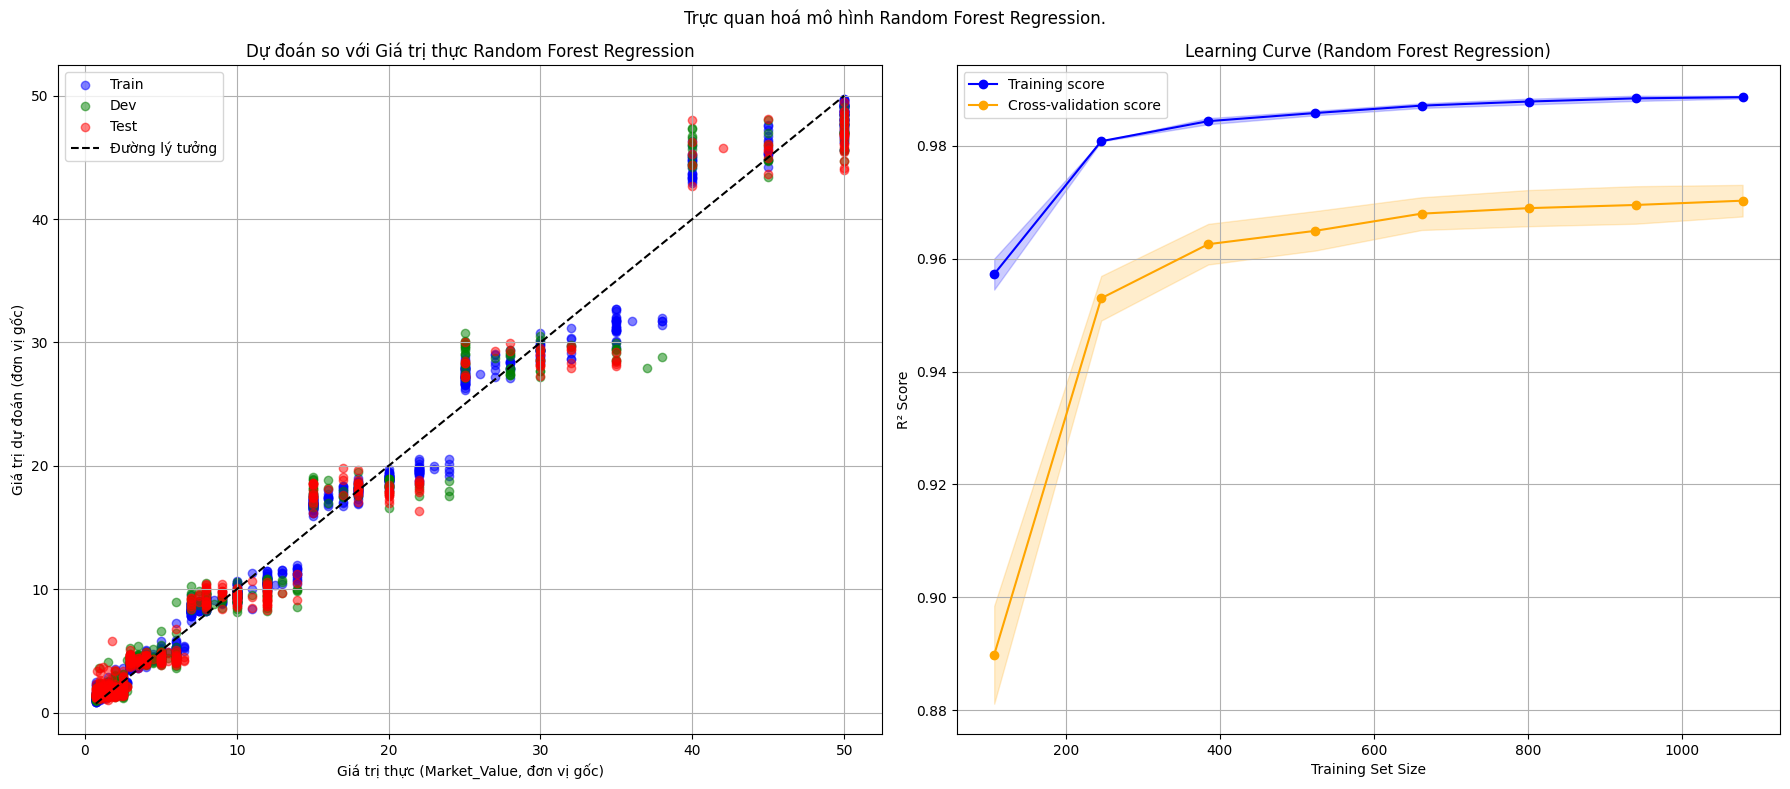

In [ ]:
best_model_RF_Win.fit (X_train_sel, y_train)

y_train_pred = best_model_RF_Win.predict(X_train_sel)
y_dev_pred = best_model_RF_Win.predict(X_dev_sel)
y_test_pred = best_model_RF_Win.predict(X_test_sel)

# 5. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'Random Forest Regression', best_model_RF_Win, data_rf)

# 8. Trực quan hoá 
module.Visualize (best_model_RF_Win, 'Random Forest Regression', X_train_sel, y_train, y_train, y_train_pred, y_dev_pred, y_test_pred)

`Nhận xét:`

- Train: MSE cao hơn model 2 và 3, tức mô hình chưa fit dữ liệu train sâu lắm; R2 vẫn khá cao (>0.98).

- Dev/Test: MSE và R2 khá tốt, test MSE thấp nhất trong 3 model (3.7566).

- Lỗi phần trăm (MAPE, sMAPE) trên train cao hơn model 2, nhưng trên dev/test lại cao nhất, đặc biệt MAPE trên test tới ~31.6% — thể hiện sai số dự đoán tương đối lớn theo phần trăm.

- Có dấu hiệu underfit nhẹ ở train (MSE cao) nhưng dev/test vẫn chấp nhận được.

# XGBoost Regression

# XGBoost - Original

Tham số tối ưu: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV MSE (scaled): 64.8554
Kết quả đánh giá mô hình XGBoost Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         0.6358    0.7973    0.9983       15.93    0.5435
Dev          42.0334    6.4833    0.8536       37.76    2.6965
Test         65.2281    8.0764    0.8197       60.82    2.7178


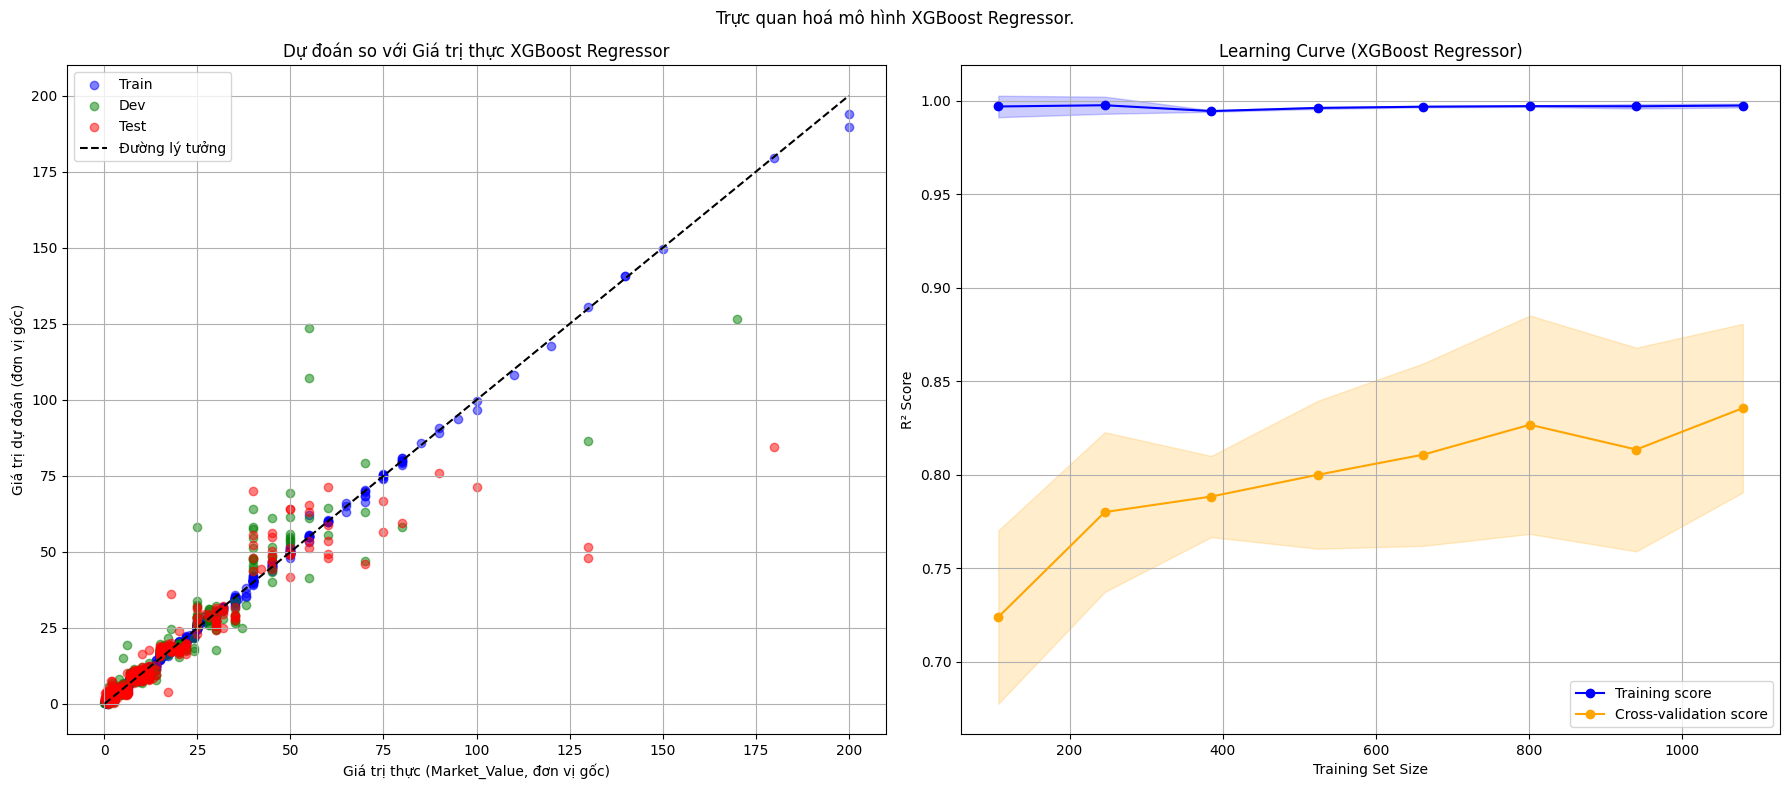

In [27]:
data_xgb = data_clean.copy ()

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_xgb.drop(columns='Market_Value').values
y = data_xgb['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 3. Tìm bộ siêu tham số tối ưu bằng RandomSearchGV
xgb = XGBRegressor(random_state=42, objective='reg:squarederror',verbosity=0)
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}
# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=xgb_param_grid,
#     scoring='neg_mean_squared_error',  # hoặc 'r2', tùy mục tiêu
#     cv=5,
#     verbose=0,
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)
random_search = RandomizedSearchCV (
    estimator=xgb,
    param_distributions=xgb_param_grid,
    scoring='neg_mean_squared_error',  # hoặc 'r2', tùy mục tiêu
    cv=5,
    n_iter=50,
    verbose=0,
    n_jobs=-1
)
random_search.fit (X_train, y_train)
# 4. Lấy mô hình tốt nhất
best_model_XGB_Orig = random_search.best_estimator_
print(f"Tham số tối ưu: {random_search.best_params_}")
print(f"Best CV MSE (scaled): {-random_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_XGB_Orig.predict(X_train)
y_dev_pred = best_model_XGB_Orig.predict(X_dev)
y_test_pred = best_model_XGB_Orig.predict(X_test)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'XGBoost Regressor', best_model_XGB_Orig, data_svm)

# 8. Trực quan hoá 
module.Visualize (best_model_XGB_Orig, 'XGBoost Regressor', X_train, y_train,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

## XGBoost - IQR

--> XGBoost bị ảnh hưởng rất nặng bởi Outlier

Số lượng mẫu sau khi lọc: 2067
Tham số tối ưu: {'subsample': 0.7, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV MSE (scaled): 4.2600
Kết quả đánh giá mô hình XGBoost Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.3557    1.5348    0.9710       38.34    1.1387
Dev           3.8764    1.9689    0.9511       36.26    1.4230
Test          3.5029    1.8716    0.9496       36.66    1.3427


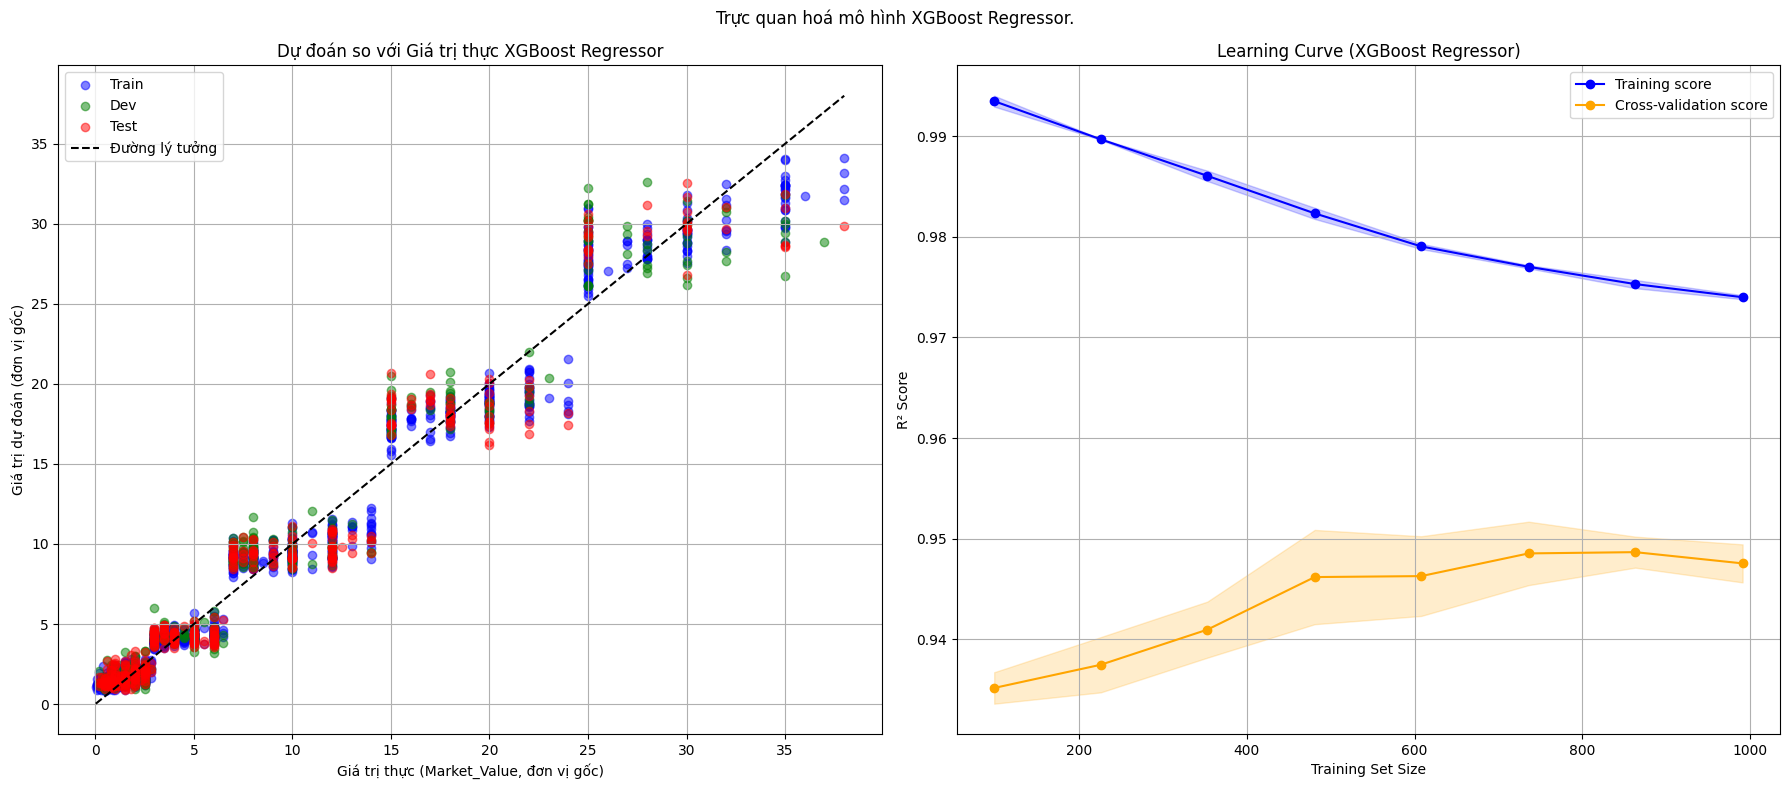

In [33]:
data_xgb = data_clean.copy ()
data_xgb = module.remove_outliers_iqr (data_xgb)
print ('Số lượng mẫu sau khi lọc:', len (data_xgb))

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_xgb.drop(columns='Market_Value').values
y = data_xgb['Market_Value'].values
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 3. Tìm bộ siêu tham số tối ưu bằng RandomSearchGV
xgb = XGBRegressor(random_state=42, objective='reg:squarederror',verbosity=0)
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}
# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=xgb_param_grid,
#     scoring='neg_mean_squared_error',  # hoặc 'r2', tùy mục tiêu
#     cv=5,
#     verbose=0,
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)
random_search = RandomizedSearchCV (
    estimator=xgb,
    param_distributions=xgb_param_grid,
    scoring='neg_mean_squared_error',  # hoặc 'r2', tùy mục tiêu
    cv=5,
    n_iter=50,
    verbose=0,
    n_jobs=-1
)
random_search.fit (X_train, y_train)
# 4. Lấy mô hình tốt nhất
best_model_XGB_IQR = random_search.best_estimator_
print(f"Tham số tối ưu: {random_search.best_params_}")
print(f"Best CV MSE (scaled): {-random_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_XGB_IQR.predict(X_train)
y_dev_pred = best_model_XGB_IQR.predict(X_dev)
y_test_pred = best_model_XGB_IQR.predict(X_test)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'XGBoost Regressor', best_model_XGB_IQR, data_svm)

# 8. Trực quan hoá 
module.Visualize (best_model_XGB_IQR, 'XGBoost Regressor', X_train, y_train,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

In [34]:
importance = best_model_XGB_IQR.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance.keys()),
    'Importance': list(importance.values())
}).sort_values(by='Importance', ascending=False)

print(importance_df)

   Feature   Importance
37     f44  4750.744141
35     f41  2722.807861
36     f42   744.702087
34     f40    82.025093
26     f30    68.327057
6       f6    40.789253
5       f5    40.753597
4       f4    34.146301
0       f0    33.181870
13     f15    32.183506
16     f18    27.563826
22     f26    26.317110
15     f17    25.798040
7       f7    25.545702
20     f24    23.254517
33     f39    22.826735
1       f1    22.282797
17     f19    21.952053
9       f9    21.591206
28     f32    20.856501
18     f20    20.469797
11     f12    20.432257
2       f2    20.300585
24     f28    20.265049
21     f25    20.158146
14     f16    20.065605
29     f33    19.520935
19     f22    19.319693
23     f27    18.922136
3       f3    16.528967
25     f29    14.043309
27     f31    13.922137
8       f8    13.295789
12     f14    12.932716
31     f35    12.611528
30     f34    10.636404
10     f10    10.410686
32     f38     8.015531


### Reuse Model


Đặc trưng được chọn: ['Age', 'Height', 'Months_left', 'Mins', 'Goals', 'Assists', 'PS%', 'Rating', 'ThrbAss', 'BlkSh', 'BlkPs', 'TotClr', 'Fouled', 'Fouls', 'TotInt', 'UnTch', 'League_EPL', 'League_Ligue1', 'Continent_Grouped_Other', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 45
Số đặc trưng sau khi chọn: 23
Kết quả đánh giá mô hình XGBoost Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.3848    1.5443    0.9707       37.97    1.1429
Dev           4.0315    2.0079    0.9491       36.83    1.4350
Test          3.4992    1.8706    0.9497       34.89    1.3320


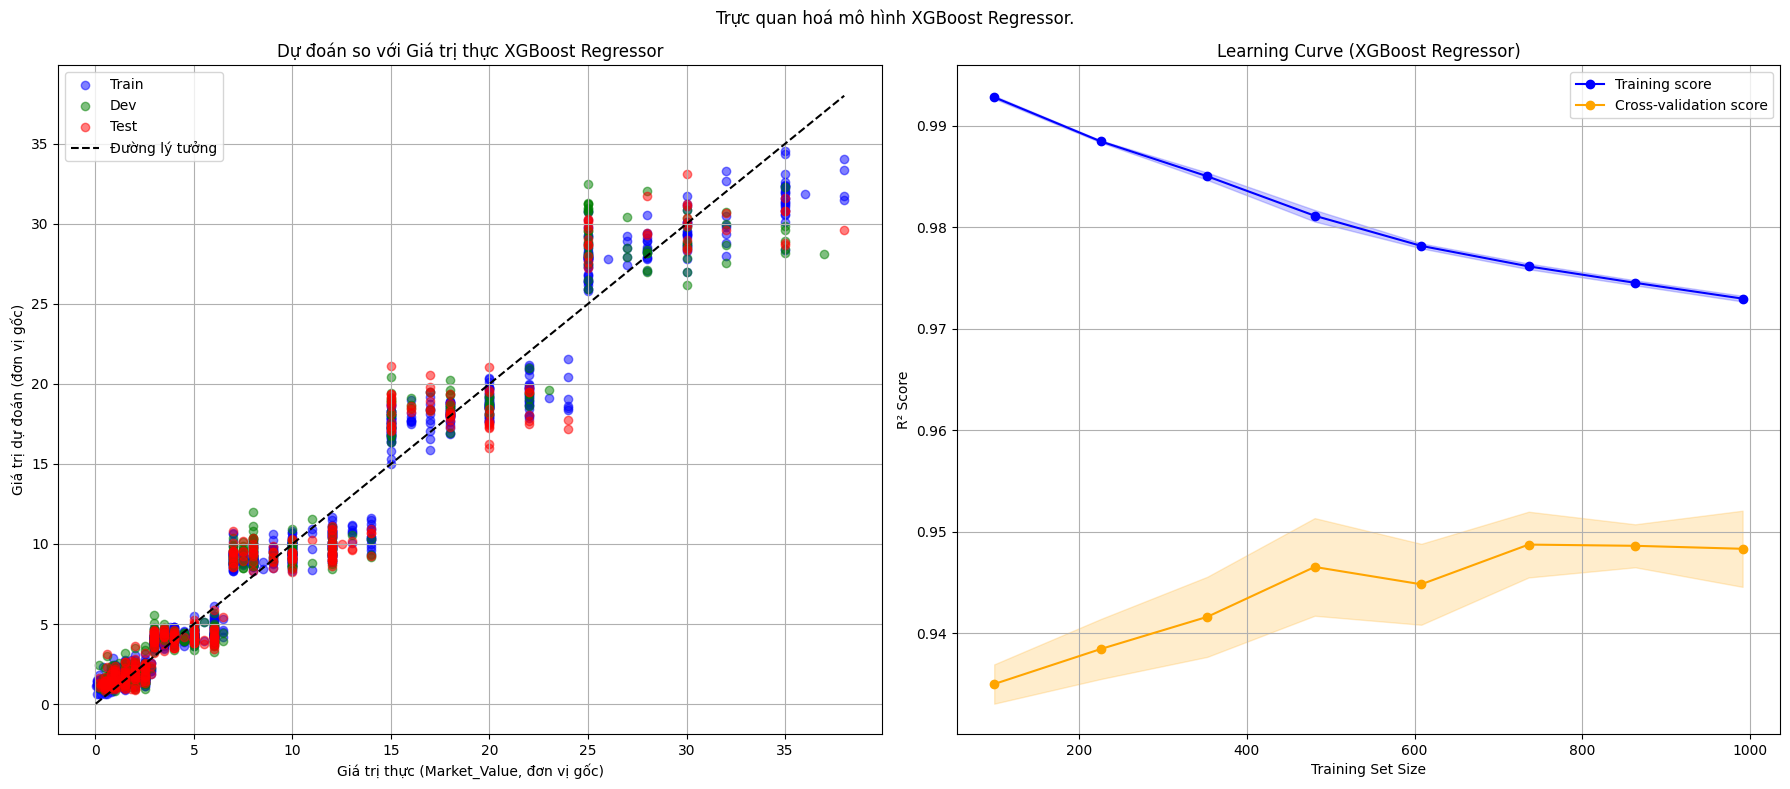

In [38]:
selector = SelectFromModel(best_model_XGB_IQR, threshold="median")
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_dev_selected = selector.transform(X_dev)
X_test_selected = selector.transform(X_test)

selected_features = data_xgb.drop ('Market_Value', axis=1).columns[selector.get_support()].tolist()
print(f"\nĐặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

xg_selected = best_model_XGB_IQR.fit (X_train_selected, y_train)

y_train_pred = best_model_XGB_IQR.predict(X_train_selected)
y_dev_pred = best_model_XGB_IQR.predict(X_dev_selected)
y_test_pred = best_model_XGB_IQR.predict(X_test_selected)

results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

module.Print (results, 'XGBoost Regressor', best_model_XGB_IQR, data_svm)

module.Visualize (best_model_XGB_IQR, 'XGBoost Regressor', X_train_selected, y_train,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)

In [40]:
from statsmodels.stats.stattools import durbin_watson

# Tính phần dư trên tập Test (hoặc Dev)
residuals = y_test - y_test_pred.ravel() 

# # Áp dụng Durbin-Watson Test
dw_stat = durbin_watson(residuals)

print(f'Durbin-Watson statistic: {dw_stat:.3f}')


Durbin-Watson statistic: 2.042


## XGBoost bằng Winsorizing

Tham số tối ưu: {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 1, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}
Best CV MSE (scaled): 5.2962
Kết quả đánh giá mô hình XGBoost Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.6127    1.6164    0.9856       22.68    1.1945
Dev           4.9799    2.2316    0.9724       26.32    1.5817
Test          4.1099    2.0273    0.9779       32.81    1.4629


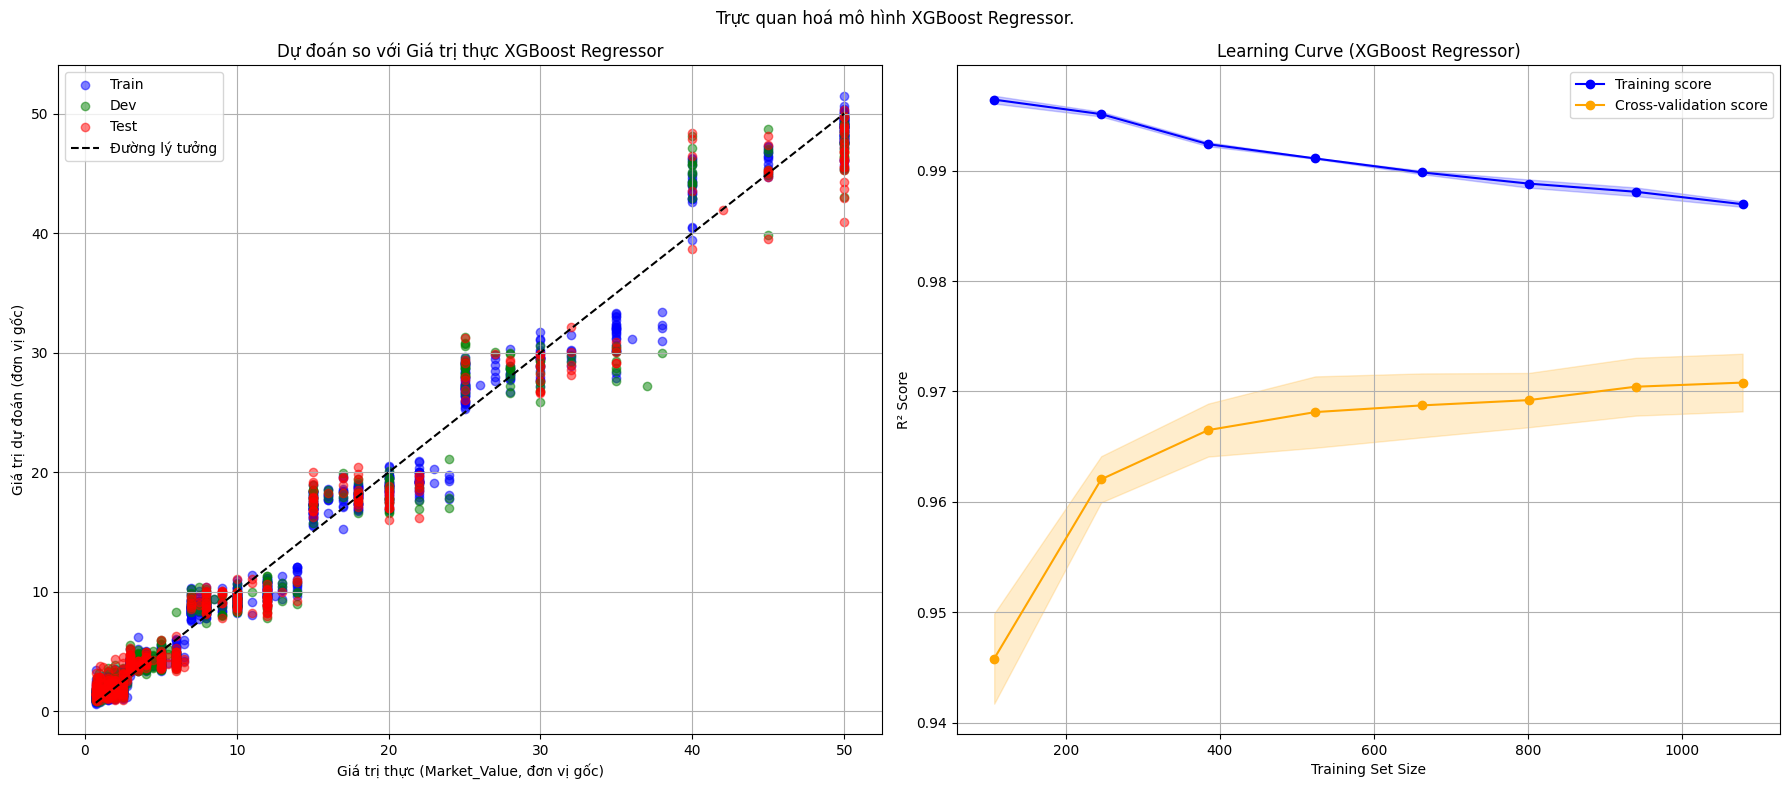

In [39]:
data_xgb = data_clean.copy () # Biến data_rg dành cho Ridge Regression
y_winsorized = module.winsorize_data (data_xgb['Market_Value'])

# 1. Thực hiện chia dữ liệu: Train (60%), Dev (20%) và Test (20%)
X = data_xgb.drop(columns='Market_Value').values # chuyển sang numpy array
y = y_winsorized
X_train, y_train, X_dev, y_dev, X_test, y_test = module.Splitting_Train_Dev_Test (X, y)

# 3. Tìm bộ siêu tham số tối ưu bằng RandomSearchGV
xgb = XGBRegressor(random_state=42, objective='reg:squarederror',verbosity=0)
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}
# grid_search = GridSearchCV(
#     estimator=xgb,
#     param_grid=xgb_param_grid,
#     scoring='neg_mean_squared_error',  # hoặc 'r2', tùy mục tiêu
#     cv=5,
#     verbose=0,
#     n_jobs=-1
# )
# grid_search.fit(X_train, y_train)
random_search = RandomizedSearchCV (
    estimator=xgb,
    param_distributions=xgb_param_grid,
    scoring='neg_mean_squared_error',  # hoặc 'r2', tùy mục tiêu
    cv=5,
    n_iter=50,
    verbose=0,
    n_jobs=-1
)
random_search.fit (X_train, y_train)
# 4. Lấy mô hình tốt nhất
best_model_XGB_Win = random_search.best_estimator_
print(f"Tham số tối ưu: {random_search.best_params_}")
print(f"Best CV MSE (scaled): {-random_search.best_score_:.4f}")

# 5. Dự đoán
y_train_pred = best_model_XGB_Win.predict(X_train)
y_dev_pred = best_model_XGB_Win.predict(X_dev)
y_test_pred = best_model_XGB_Win.predict(X_test)

# 6. Đánh giá mô hình
results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

# 7. In kết quả đánh giá mô hình Ridge với alpha tối ưu
module.Print (results, 'XGBoost Regressor', best_model_XGB_Win, data_svm)

# 8. Trực quan hoá 
module.Visualize (best_model_XGB_Win, 'XGBoost Regressor', X_train, y_train,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)


Đặc trưng được chọn: ['Age', 'Months_left', 'Sub_app', 'Mins', 'Goals', 'Assists', 'PS%', 'MotM', 'Rating', 'BlkSh', 'BlkCr', 'TotClr', 'TotInt', 'League_EPL', 'League_Laliga', 'League_Ligue1', 'Position_Group_Tiền vệ', 'Continent_Grouped_Europe', 'Club_Group_Lower Tier', 'Club_Group_Mid-High Tier', 'Club_Group_Mid-Tier', 'Club_Group_Top Tier', 'Club_Group_Upper Tier']
Số đặc trưng ban đầu: 45
Số đặc trưng sau khi chọn: 23
Kết quả đánh giá mô hình XGBoost Regressor với hyperparmeter tối ưu:
Set              MSE      RMSE        R2    MAPE (%)       MAE
--------------------------------------------------------------
Train         2.7772    1.6665    0.9847       22.72    1.2328
Dev           4.9688    2.2291    0.9725       25.43    1.5627
Test          3.9360    1.9839    0.9788       31.00    1.4256


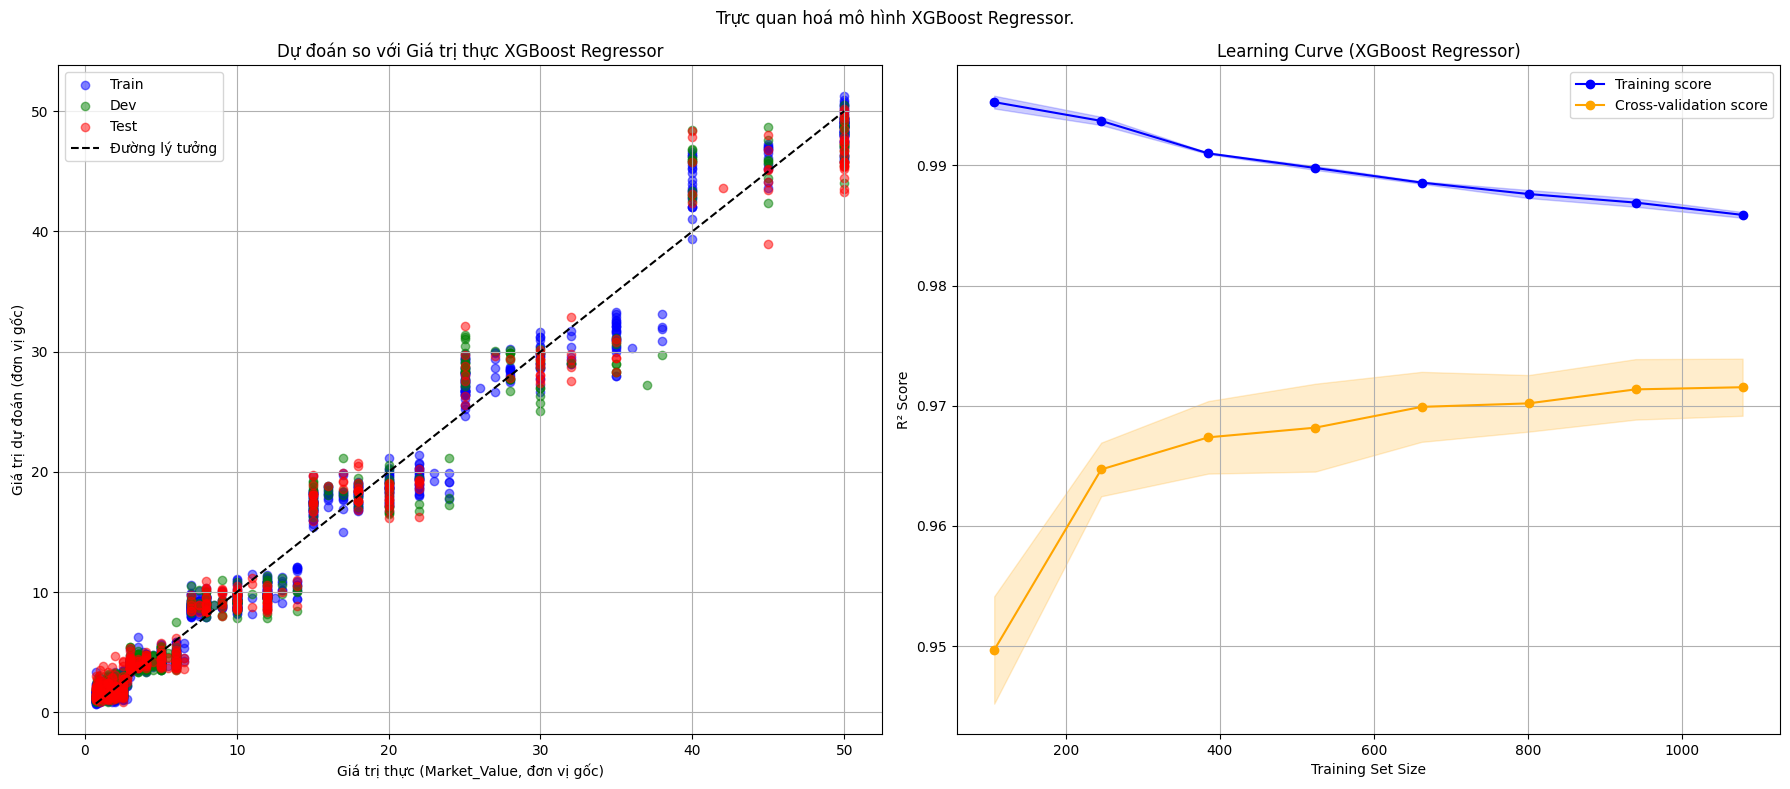

In [41]:
selector = SelectFromModel(best_model_XGB_Win, threshold="median")
selector.fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_dev_selected = selector.transform(X_dev)
X_test_selected = selector.transform(X_test)

selected_features = data_xgb.drop ('Market_Value', axis=1).columns[selector.get_support()].tolist()
print(f"\nĐặc trưng được chọn: {selected_features}")
print(f"Số đặc trưng ban đầu: {X.shape[1]}")
print(f"Số đặc trưng sau khi chọn: {len(selected_features)}")

xg_selected = best_model_XGB_Win.fit (X_train_selected, y_train)

y_train_pred = best_model_XGB_Win.predict(X_train_selected)
y_dev_pred = best_model_XGB_Win.predict(X_dev_selected)
y_test_pred = best_model_XGB_Win.predict(X_test_selected)

results = module.Evaluate.evaluate_all(y_train, y_train_pred, y_dev, y_dev_pred, y_test, y_test_pred)

module.Print (results, 'XGBoost Regressor', best_model_XGB_Win, data_svm)

module.Visualize (best_model_XGB_Win, 'XGBoost Regressor', X_train_selected, y_train,y_train, y_dev, y_test, y_train_pred, y_dev_pred, y_test_pred)